# Cellphone Price Range Prediction using Machine Learning

## Problem Statement

- **Domain:** Consumer Electronics / Mobile Phone Industry

- **Goal:** Build a **multiclass classification model** that predicts the **price range** of a mobile phone (**Low Cost, Medium Cost, High Cost, or Very High Cost**) based on its hardware specifications and connectivity features.

- **Why it matters:** Accurately estimating a mobile phone's **price range** helps manufacturers make informed pricing decisions, optimize product positioning, and remain competitive in the smartphone market.

- **Type of Problem:** **Multiclass Classification** (Price Range: **0 = Low Cost, 1 = Medium Cost, 2 = High Cost, 3 = Very High Cost**)

- **Dataset:**
  - **datasets_11167_15520_train.csv** – Contains the hardware specifications, connectivity features, and the target variable (`price_range`) for different mobile phones.

## Data Understanding

The dataset contains mobile phone specifications and a target variable, **`price_range`**, which represents the price category of each mobile phone.

| Feature | Description |
|---|---|
| `battery_power` | Total energy capacity of the battery in mAh |
| `blue` | Indicates whether the phone supports Bluetooth (0 = No, 1 = Yes) |
| `clock_speed` | Speed of the processor in GHz |
| `dual_sim` | Indicates whether the phone supports dual SIM (0 = No, 1 = Yes) |
| `fc` | Front camera resolution in megapixels |
| `four_g` | Indicates whether the phone supports 4G (0 = No, 1 = Yes) |
| `int_memory` | Internal memory capacity in GB |
| `m_dep` | Mobile depth or thickness in cm |
| `mobile_wt` | Weight of the mobile phone in grams |
| `n_cores` | Number of processor cores |
| `pc` | Primary/rear camera resolution in megapixels |
| `px_height` | Pixel resolution height |
| `px_width` | Pixel resolution width |
| `ram` | RAM capacity in MB |
| `sc_h` | Screen height in cm |
| `sc_w` | Screen width in cm |
| `talk_time` | Maximum battery life during continuous phone calls in hours |
| `three_g` | Indicates whether the phone supports 3G (0 = No, 1 = Yes) |
| `touch_screen` | Indicates whether the phone has a touchscreen (0 = No, 1 = Yes) |
| `wifi` | Indicates whether the phone supports Wi-Fi (0 = No, 1 = Yes) |
| `price_range` | Target variable representing the phone's price category |

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv("datasets_11167_15520_train.csv")

In [3]:
# Display the first five rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
# Display the last five rows
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [5]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 21)


In [6]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 2000
Number of columns: 21


#### The dataset contains **2000 rows** and **21 columns**. It includes **20 input features** describing mobile phone specifications and **1 target variable (`price_range`)**.

In [7]:
# Display all columns
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [8]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

#### **Insight:**

- The dataset contains **21 columns** with **2000 non-null observations** in each column, indicating that **no missing values** are present.
- The features consist of **integer** and **floating-point** data types. Most variables are numerical, while some represent **binary categorical features** encoded as **0 (No)** and **1 (Yes)**.

In [9]:
# Display summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


#### **Insights:**

- The dataset contains mobile phones with a **wide range of hardware specifications**, including **battery power (501–1998 mAh)**, **RAM (256–3998 MB)**, and **internal memory (2–64 GB)**, representing different price segments.
- Display features such as **screen resolution** and **screen dimensions** vary across devices, indicating diversity in mobile phone configurations.
- Connectivity features like **Bluetooth**, **Dual SIM**, **3G**, **4G**, **Touch Screen**, and **Wi-Fi** are **binary categorical variables***, allowing the model to evaluate how these features contribute to different price categories.
- The broad variation in smartphone specifications suggests that the dataset is well-suited for identifying relationships between hardware features and mobile phone price ranges.

In [10]:
# Check the distribution of the target variable
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [11]:
df['price_range'].value_counts(normalize=True)*100

price_range
1    25.0
2    25.0
3    25.0
0    25.0
Name: proportion, dtype: float64

#### The target variable **`price_range`** is **perfectly balanced**, with **500 mobile phones** in each of the four price categories. Since all four price-range classes are equally represented, the dataset does not exhibit class imbalance. Therefore, **oversampling techniques such as SMOTE are not required.**

In [12]:
# Check for missing values
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

#### All features contain complete data with **no missing values**, making the dataset ready for **exploratory data analysis (EDA)** and **preprocessing** without requiring **missing value imputation**.

### Duplicate Value Analysis
Checking for duplicate records helps ensure that **each mobile phone is represented only once** in the dataset. Duplicate records can introduce bias and affect the performance of machine learning models.

In [13]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

#### No duplicate records are present in the dataset, indicating that **each mobile phone is represented only once** and the dataset is ready for further analysis.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the mobile phone dataset by analyzing the distribution of features, identifying patterns, detecting outliers, and exploring relationships between smartphone specifications and price range. These insights support effective data preprocessing and machine learning model development.

## Univariate Analysis

Univariate analysis is performed to examine the distribution of individual features in the dataset. It helps understand the range, variability, and distribution pattern of each smartphone specification, providing valuable insights before model building.

To ensure a systematic and organized analysis, the target variable is analyzed first, followed by grouping related features based on their functionality. This approach improves readability, facilitates meaningful comparisons among similar smartphone specifications, and reduces repetitive visualizations.

The features are grouped as follows:

- **Target Variable:** Price Range.
- **Hardware Specifications:** Battery Power, RAM, Internal Memory, Clock Speed, Number of Cores, and Mobile Weight.
- **Camera Features:** Front Camera and Primary Camera.
- **Display Features:** Pixel Height, Pixel Width, Screen Height, and Screen Width.
- **Connectivity & Device Features:** blue, dual_sim, three_g, four_g, wifi, touch_screen
- **Other Device Characteristics:** Mobile Depth and Talk Time.

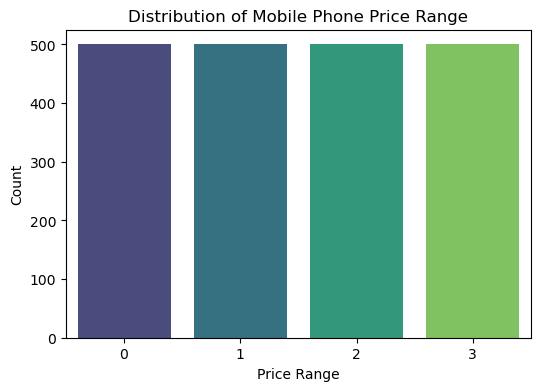

In [14]:
# Visualize the distribution of the target variable

plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title("Distribution of Mobile Phone Price Range")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

#### **Insights:**
- The dataset includes an **equal representation of mobile phones across all four price categories**, ensuring that each market segment is well represented.
- This balanced distribution enables a fair comparison of cellphone specifications across different price ranges and supports reliable pattern analysis.

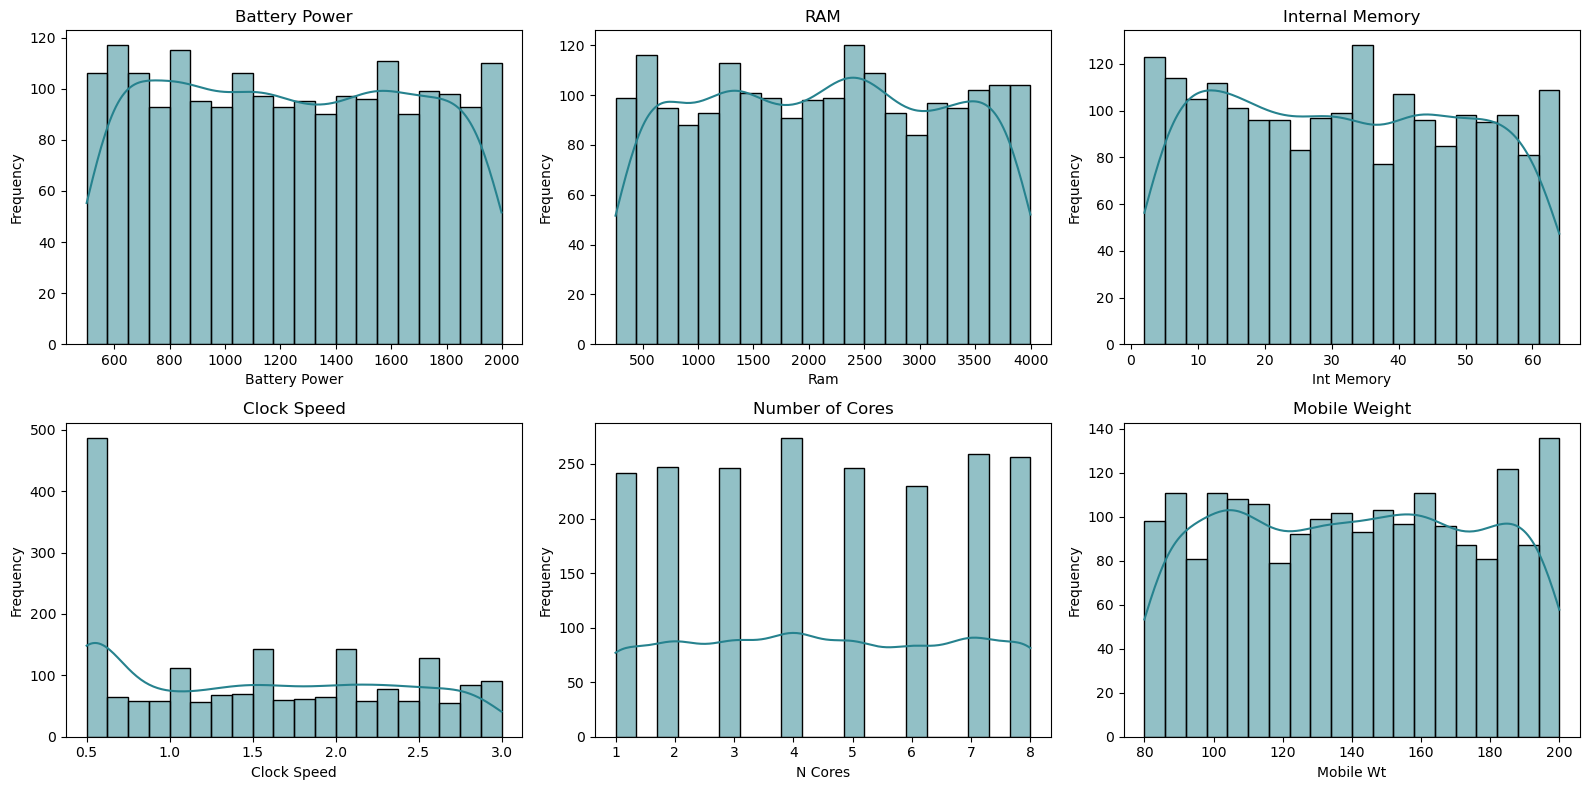

In [15]:
# Hardware Specification Distributions

hardware_features = ['battery_power', 'ram', 'int_memory', 'clock_speed', 'n_cores', 'mobile_wt']
titles = ['Battery Power', 'RAM', 'Internal Memory', 'Clock Speed', 'Number of Cores', 'Mobile Weight']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(hardware_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color = '#26828E')
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### **Insights:**

- The hardware specifications exhibit **diverse value ranges**, indicating that the dataset includes cellphones with varying performance levels, from entry-level to premium devices.
- **Battery Power**, **RAM**, **Internal Memory**, and **Mobile Weight** are fairly well distributed across their respective ranges, providing sufficient variation for the model to learn how these specifications influence different price categories.
- **Clock Speed** shows a noticeable concentration around **0.5 GHz**, while the remaining values are distributed across higher speeds, suggesting that lower clock-speed devices are more common in the dataset.
- The **Number of CPU Cores** is distributed across **1 to 8 cores**, indicating that smartphones with different processing capabilities are represented, which may contribute to distinguishing price segments.
- Overall, the balanced distribution and variability of these hardware features provide meaningful information for predicting the **cellphone price range**.

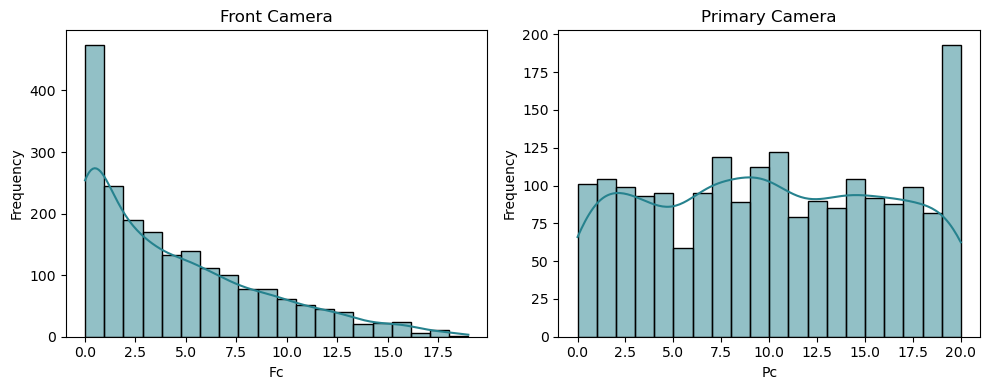

In [16]:
# Camera Feature Distributions

camera_features = ['fc', 'pc']
titles = ['Front Camera', 'Primary Camera']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(camera_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color = '#26828E')
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### **Insights:**

- The **Front Camera** distribution is **right-skewed**, indicating that most cellphones in the dataset have lower front camera resolutions, while high-resolution selfie cameras are less common.
- The **Primary Camera** values are spread across a wide range of resolutions, with a **noticeable concentration around 20 MP**, suggesting that many smartphones are equipped with high-resolution rear cameras.
- The variation in both **camera resolutions** indicates that imaging specifications differ across cellphones and may help distinguish different **price categories**.

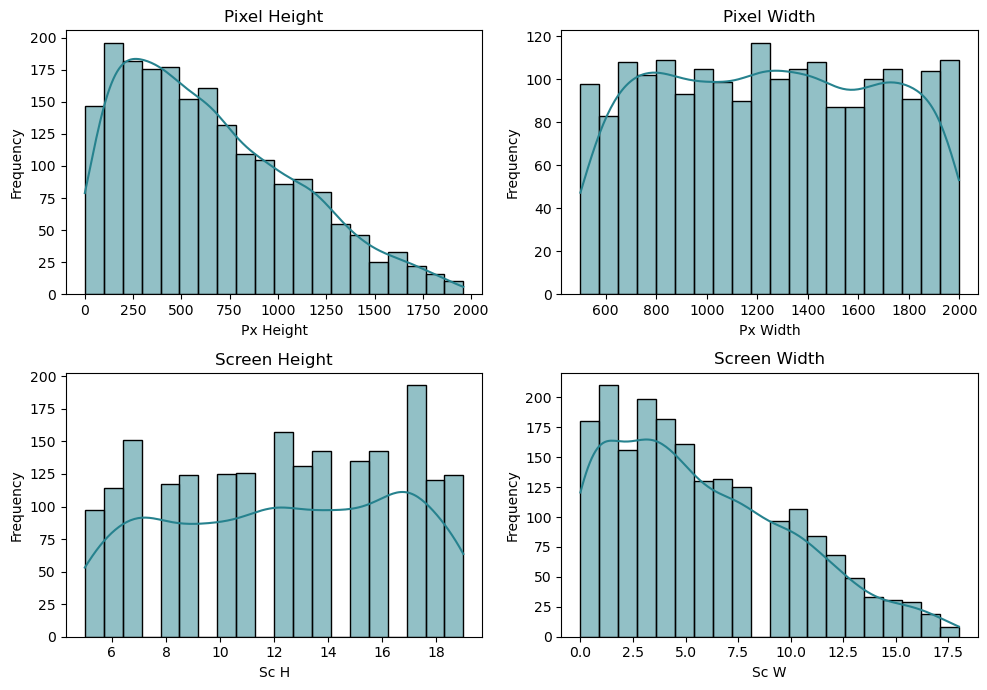

In [17]:
# Display Feature Distributions

display_features = ['px_height', 'px_width', 'sc_h', 'sc_w']
titles = ['Pixel Height', 'Pixel Width', 'Screen Height', 'Screen Width']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feature in enumerate(display_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color = '#26828E')
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### **Insights:**

- **Pixel Height** and **Screen Width** show **right-skewed distributions**, indicating that lower values are more common, while larger display dimensions occur less frequently.
- **Pixel Width** is relatively well distributed across its range, showing considerable variation in the horizontal display resolution among cellphones.
- **Screen Height** is spread across a broad range, with a noticeable concentration around **17 units**, indicating that this screen dimension is relatively common in the dataset.
- The variation in **display resolution and screen dimensions** indicates differences in smartphone display characteristics and may provide useful information for distinguishing different **price categories**.

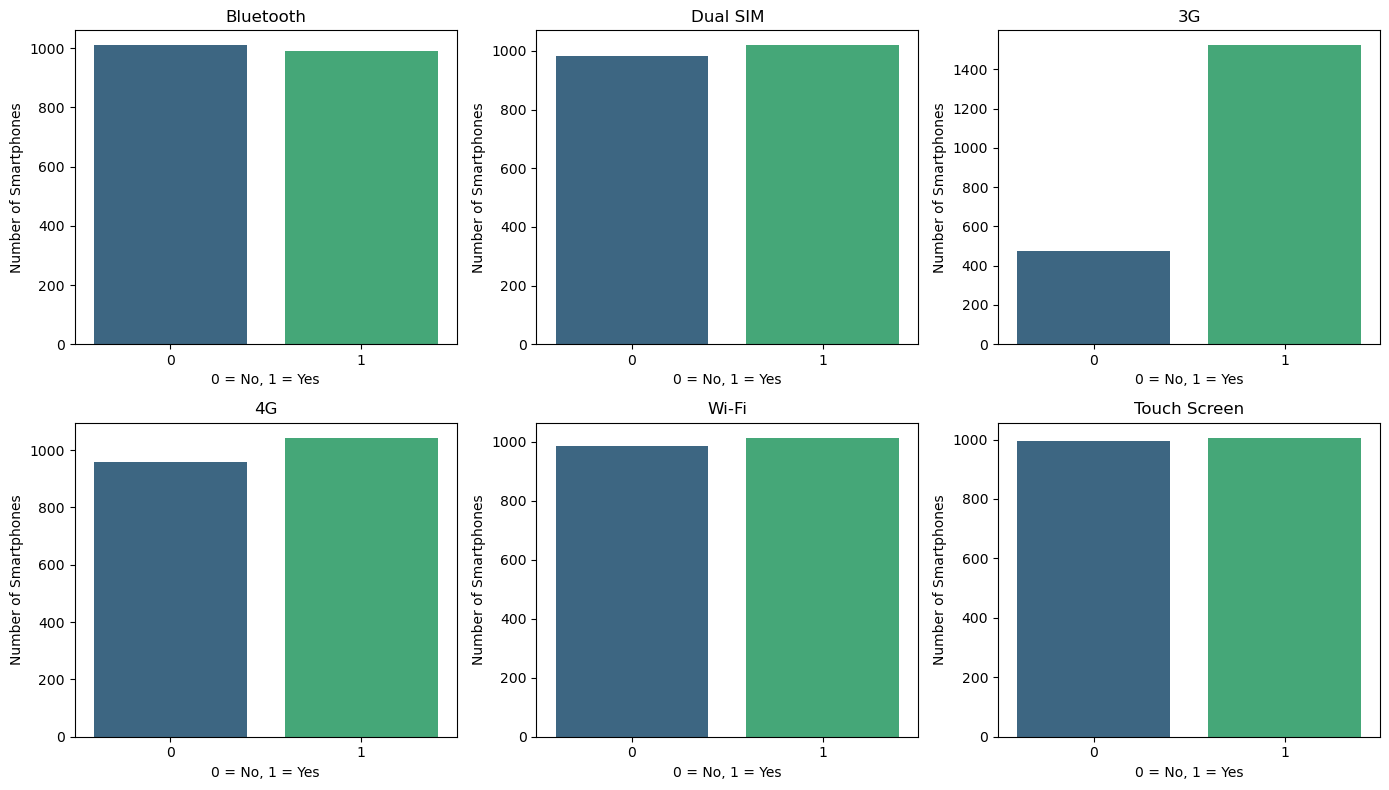

In [18]:
# Connectivity & Device Features Distribution

connectivity_device_features = ['blue', 'dual_sim', 'three_g', 'four_g', 'wifi', 'touch_screen']
titles = ['Bluetooth', 'Dual SIM', '3G', '4G', 'Wi-Fi', 'Touch Screen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(connectivity_device_features):
    sns.countplot(x=df[feature], ax=axes[i], palette=['#31688E', '#35B779'])
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel("0 = No, 1 = Yes")
    axes[i].set_ylabel("Number of Smartphones")

plt.tight_layout()
plt.show()

In [19]:
# Statistical summary of Connectivity & Device Features

connectivity_features = ['blue', 'dual_sim', 'three_g', 'four_g', 'wifi', 'touch_screen']
summary = pd.DataFrame({
    'Count (0)': [df[col].value_counts().get(0, 0) for col in connectivity_features],
    'Count (1)': [df[col].value_counts().get(1, 0) for col in connectivity_features],
    'Percentage (0)': [
        (df[col].value_counts(normalize=True).get(0, 0) * 100).round(2)
        for col in connectivity_features
    ],
    'Percentage (1)': [
        (df[col].value_counts(normalize=True).get(1, 0) * 100).round(2)
        for col in connectivity_features
    ]
}, index=connectivity_features)

summary

,Count (0),Count (1),Percentage (0),Percentage (1)
blue,1010,990,50.50,49.50
dual_sim,981,1019,49.05,50.95
three_g,477,1523,23.85,76.15
four_g,957,1043,47.85,52.15
wifi,986,1014,49.30,50.70
touch_screen,994,1006,49.70,50.30


#### **Insights:**

- **Bluetooth, Dual SIM, Wi-Fi, and Touch Screen** have relatively balanced distributions between `0` and `1`, with both feature-enabled and feature-disabled cellphones well represented in the dataset. The statistical summary shows that the proportions for these features are close to **50% each**.
- **3G support** is clearly more prevalent, with approximately **76% of cellphones supporting 3G**, compared with about **24% without 3G support**.
- **4G support** is relatively balanced overall, with approximately **52% of cellphones supporting 4G** and **48% without 4G support**, despite being less widespread than 3G.
- Overall, the variation in **connectivity and device features** provides useful information for analyzing how cellphone specifications differ across **price categories**.

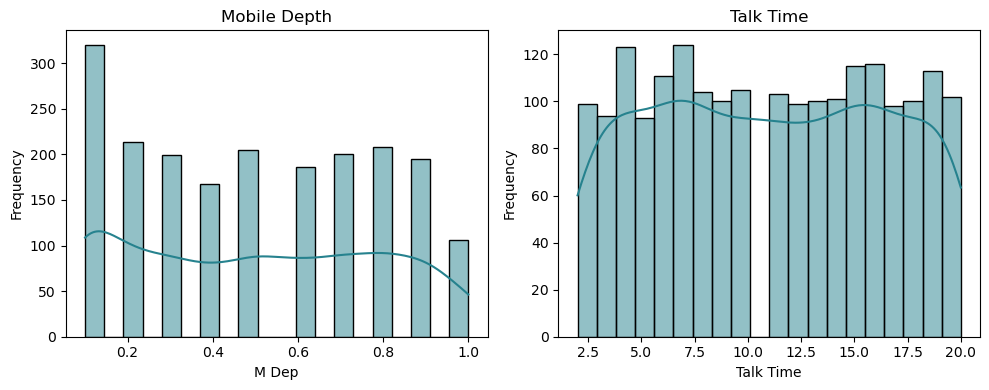

In [20]:
# Other Device Characteristics Distribution

other_features = ['m_dep', 'talk_time']
titles = ['Mobile Depth', 'Talk Time']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(other_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color = '#26828E')
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### **Insights:**

- **Mobile Depth** values are distributed across the range, with a higher frequency of smartphones at the lower depth values, indicating that slimmer devices are well represented in the dataset.
- **Talk Time** is fairly evenly distributed across its range, showing that smartphones with different battery usage capacities are well represented.
- Overall, the variation in **mobile thickness and talk-time capability** provides additional information about differences in smartphone characteristics that may help distinguish between **price categories**.

## Bivariate Analysis

Bivariate analysis is performed to examine the relationship between individual cellphone features and the target variable, **Price Range**. It helps identify patterns, trends, and differences in cellphone specifications across the four price categories, providing insights into which features may contribute to price differentiation.

The bivariate analysis follows the **feature groupings established in the Univariate Analysis**. Related features are analyzed together where appropriate to facilitate meaningful comparisons and maintain a clear, organized analysis while avoiding repetitive visualizations.

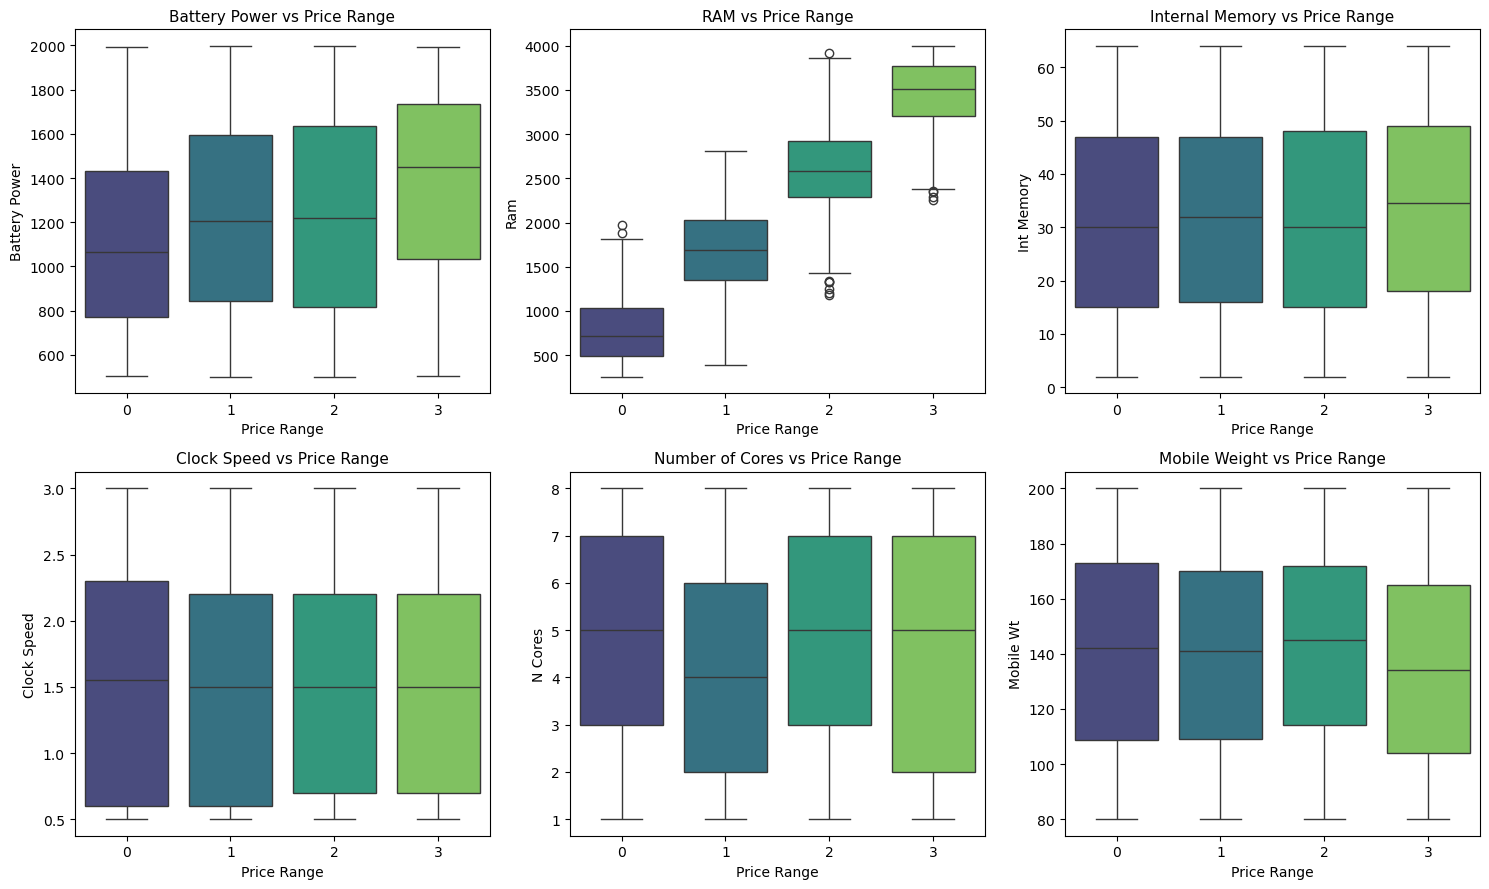

In [21]:
# Hardware Specifications vs Price Range

hardware_features = ['battery_power', 'ram', 'int_memory', 'clock_speed', 'n_cores', 'mobile_wt']
titles = [
    'Battery Power vs Price Range',
    'RAM vs Price Range',
    'Internal Memory vs Price Range',
    'Clock Speed vs Price Range',
    'Number of Cores vs Price Range',
    'Mobile Weight vs Price Range'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(hardware_features):
    sns.boxplot(x='price_range', y=feature, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_xlabel('Price Range')
    axes[i].set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

#### **Insights:**

- **Battery Power** shows an upward trend across the price ranges, particularly in the higher price categories, suggesting that cellphones in higher price ranges tend to have greater battery capacity. However, the overlap between the categories indicates that Battery Power alone may not be sufficient to distinguish all price ranges.
- **RAM** shows the **strongest and clearest relationship with price range** among the hardware specifications. The median RAM increases substantially from price range 0 to 3, indicating that higher-priced smartphones generally offer significantly higher RAM capacity.
- **Internal Memory** shows a slight increase in median values but considerable overlap across price ranges, suggesting weaker separation than RAM.
- **Clock Speed, Number of Cores, and Mobile Weight** show substantial overlap across the price categories, with no consistent trend in their median values. This indicates a weaker individual relationship with smartphone price range.
- Overall, **RAM and Battery Power appear to be the most distinguishing hardware specifications**, while **Internal Memory, Clock Speed, Number of Cores, and Mobile Weight** provide weaker individual separation between the price categories.

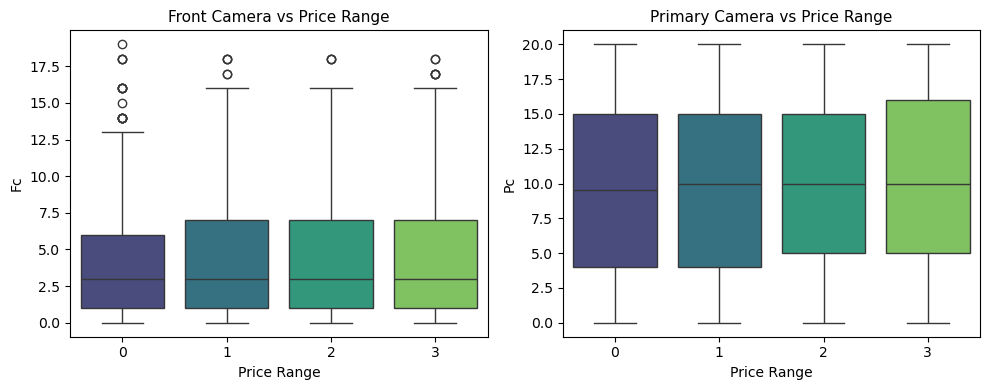

In [22]:
# Camera Features vs Price Range

camera_features = ['fc', 'pc']
titles = [
    'Front Camera vs Price Range',
    'Primary Camera vs Price Range'
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(camera_features):
    sns.boxplot(x='price_range', y=feature, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_xlabel('Price Range')
    axes[i].set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

#### **Insights:**
- **Front Camera** shows nearly identical median values across all four price ranges, with substantial overlap, indicating that front camera resolution is a weak individual indicator of price range.
- **Primary Camera** also shows similar median values across the price categories. Despite slight differences in spread, considerable overlap suggests that primary camera resolution alone does not clearly separate lower- and higher-priced cellphones.
- Overall, **neither camera feature shows a strong individual relationship with price range**, suggesting that smartphone price categories are likely determined by a **combination of multiple specifications** rather than camera resolution alone.

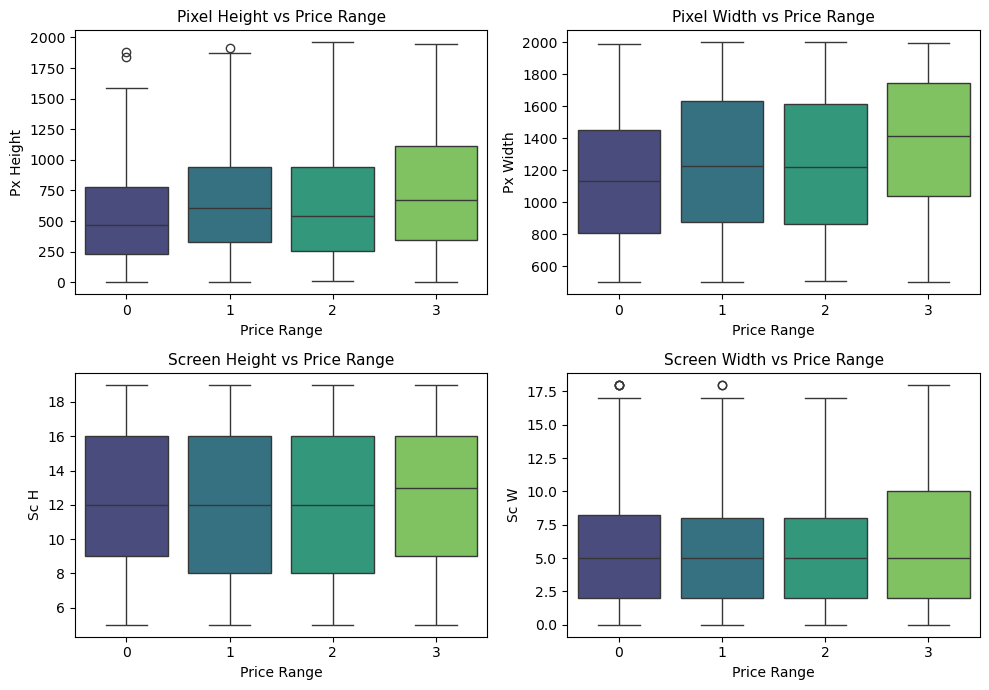

In [23]:
# Display Features vs Price Range

display_features = ['px_height', 'px_width', 'sc_h', 'sc_w']
titles = [
    'Pixel Height vs Price Range',
    'Pixel Width vs Price Range',
    'Screen Height vs Price Range',
    'Screen Width vs Price Range'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, feature in enumerate(display_features):
    sns.boxplot(x='price_range', y=feature, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_xlabel('Price Range')
    axes[i].set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

#### **Insights:**

- **Pixel Height** shows a gradual rise in median values across the price ranges, with the highest median in Price Range 3, indicating that higher-priced cellphones generally tend to have greater vertical display resolution.
- **Pixel Width** follows a similar pattern, with Price Range 3 showing the highest median, suggesting that higher-priced cellphones generally offer higher horizontal display resolution.
- **Screen Height** and **Screen Width** have relatively similar median values across the four price ranges, indicating that physical screen dimensions vary less with price than display resolution.
- Overall, **pixel-based resolution appears more closely associated with smartphone price than physical screen dimensions** in this dataset.

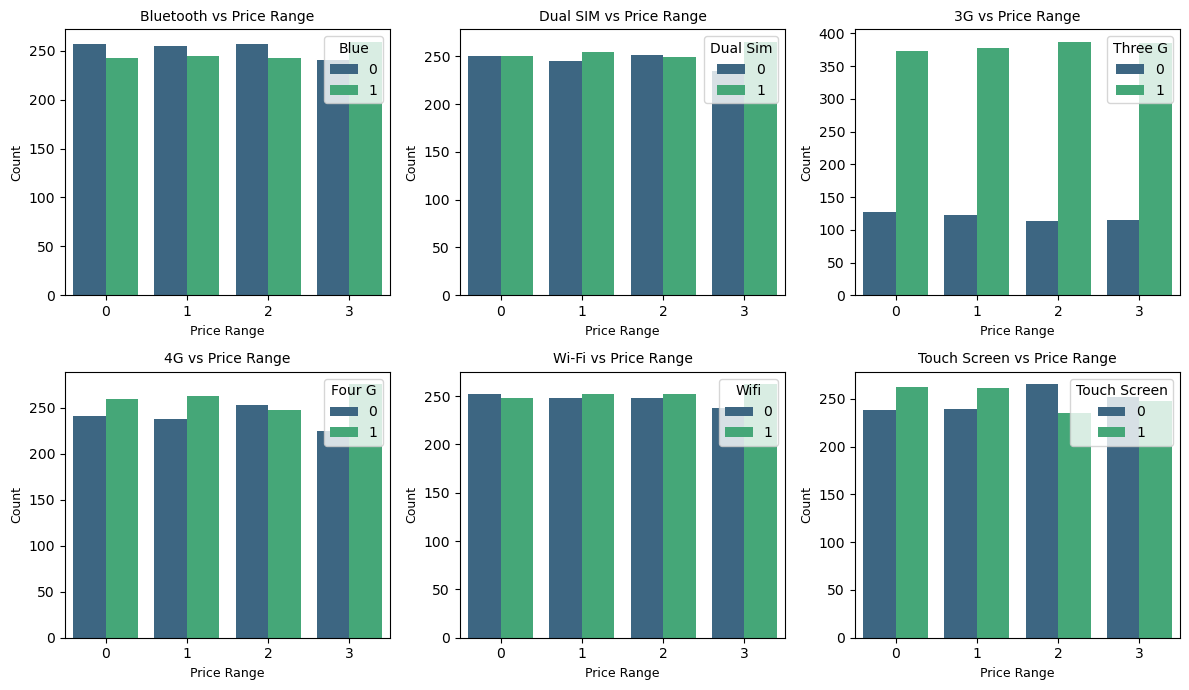

In [24]:
# Connectivity & Device Features vs Price Range

connectivity_features = [
    'blue',
    'dual_sim',
    'three_g',
    'four_g',
    'wifi',
    'touch_screen'
]

titles = [
    'Bluetooth vs Price Range',
    'Dual SIM vs Price Range',
    '3G vs Price Range',
    '4G vs Price Range',
    'Wi-Fi vs Price Range',
    'Touch Screen vs Price Range'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, feature in enumerate(connectivity_features):
    sns.countplot(data=df, x='price_range', hue=feature, ax=axes[i], palette=['#31688E', '#35B779'])
    
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].set_xlabel('Price Range', fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)
    axes[i].legend(title=feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

#### **Insights:**

- **Bluetooth, Dual SIM, and Wi-Fi** show relatively similar distributions of `0` and `1` across all four price ranges, indicating that these features do not show a strong variation with cellphone price category.
- **3G support** is consistently more prevalent across all price ranges, with only minor variation between categories. This suggests that **3G availability is not a strong differentiator of price range**.
- **4G support** shows some variation across price ranges, but the differences are not consistent enough to indicate a clear relationship with increasing cellphone price.
- **Touch Screen** is more prevalent in the lower price ranges, while the distribution becomes more balanced in the higher price ranges. This indicates that **touch-screen availability alone does not show a consistent relationship with cellphone price**.
- Overall, **these connectivity and device features show limited individual separation across price ranges**, suggesting that cellphone price classification is likely influenced more strongly by **hardware and other specifications** than by these features alone.

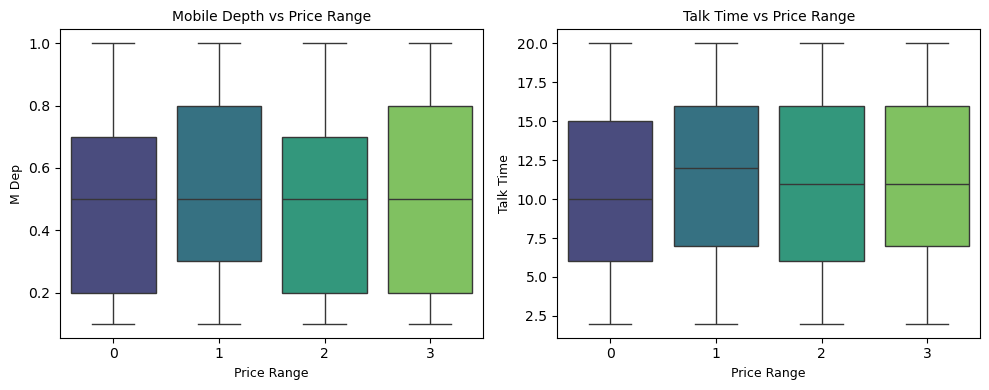

In [25]:
# Other Device Characteristics vs Price Range

other_features = [ 'm_dep', 'talk_time']
titles = ['Mobile Depth vs Price Range', 'Talk Time vs Price Range']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, feature in enumerate(other_features):
    sns.boxplot(data=df, x='price_range', y=feature, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].set_xlabel('Price Range', fontsize=9)
    axes[i].set_ylabel(feature.replace('_', ' ').title(), fontsize=9)
plt.tight_layout()
plt.show()

#### **Insights:**

- **Mobile Depth** has a stable median of around `0.5` across all price ranges, indicating that cellphone thickness remains fairly consistent regardless of price category.
- **Talk Time** records a higher median in Price Range `1`, followed by a slight decrease in the higher categories. This indicates that **longer talk time does not consistently increase with cellphone price**.
- Overall, **neither mobile depth nor talk time exhibits a clear price-based progression**, suggesting that these specifications have limited usefulness for distinguishing between the four cellphone price categories.

## Correlation Heatmap

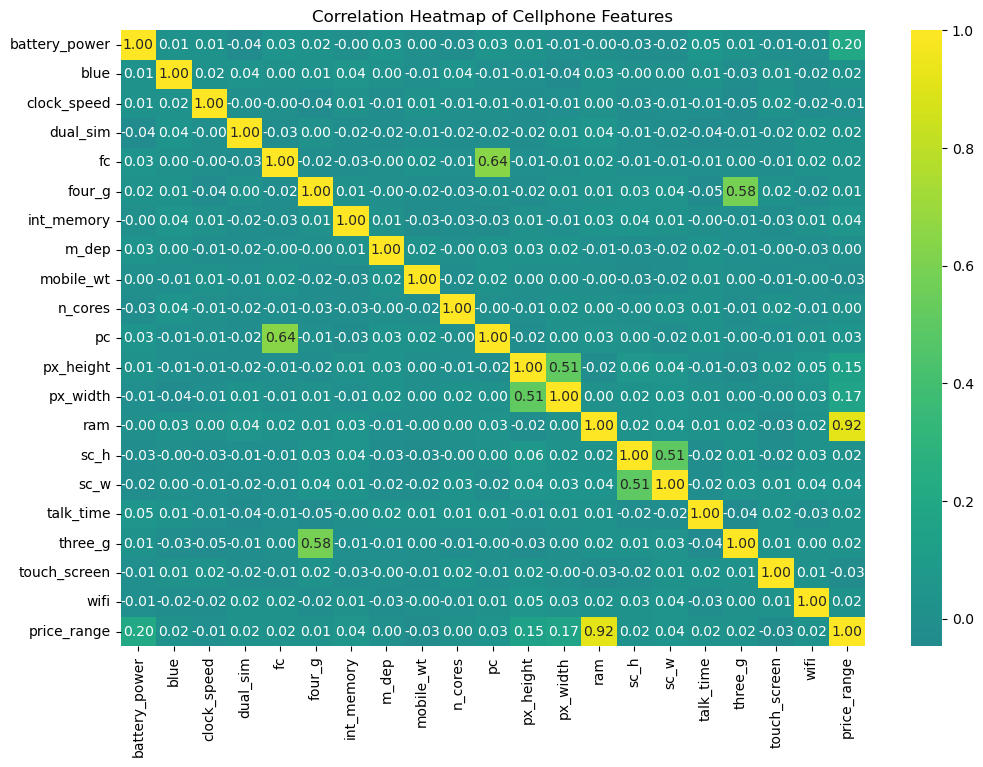

In [26]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis', center=0)

plt.title('Correlation Heatmap of Cellphone Features')
plt.show()

#### **Insights:**

- **RAM shows the strongest positive correlation with cellphone price range (r = 0.92)**, indicating that cellphones with higher RAM are strongly associated with higher price ranges. This suggests that RAM is a major specification differentiating lower-priced and higher-priced cellphones in this dataset.

- **Battery Power (r = 0.20), Pixel Width (r = 0.17), and Pixel Height (r = 0.15)** show weak positive correlations with price range, suggesting that these features have limited individual linear relationships with cellphone price.

- The remaining features show **very weak or negligible linear correlations with price range**. However, this does not mean they are unimportant, as machine learning models can capture non-linear relationships and interactions among features.

- Among the independent features, **Front Camera and Primary Camera (r = 0.64)**, **Four G and Three G (r = 0.58)**, and **Pixel Height and Pixel Width (r = 0.51)** show relatively stronger correlations, indicating that some cellphone specifications naturally vary together.

- Overall, the correlation analysis indicates that **RAM has the strongest linear association with cellphone price range**, while other cellphone specifications may also contribute to price-range prediction through their individual and combined relationships. These relationships will be further explored through **multivariate analysis using a pairplot**.

## Multivariate Analysis

### Feature Selection for Multivariate Analysis

The following features were selected for multivariate analysis based on the findings from the **univariate, bivariate, and correlation analysis**. The selection was made to examine the **joint relationships and distribution of key cellphone specifications across the four price ranges**:

- **RAM** – Selected because it showed the **strongest positive relationship with `price_range`** and was the most prominent price-related feature identified during the correlation analysis.
- **Battery Power** – Selected because it showed a **positive relationship with `price_range`** and to examine whether its combination with RAM provides clearer patterns across different price categories.
- **Pixel Width and Pixel Height** – Selected because they represent **display resolution specifications**, showed a positive relationship with `price_range`, and also exhibited a relationship with each other. They were analyzed together to explore their combined patterns across the four price ranges.
- **Price Range** – Used as the target variable to distinguish the four price categories through color grouping.

This focused feature selection allows us to examine whether these key cellphone specifications, when considered together, reveal **meaningful patterns, interactions, or clearer separation among the different price ranges** that may not be evident when analyzing each feature individually.

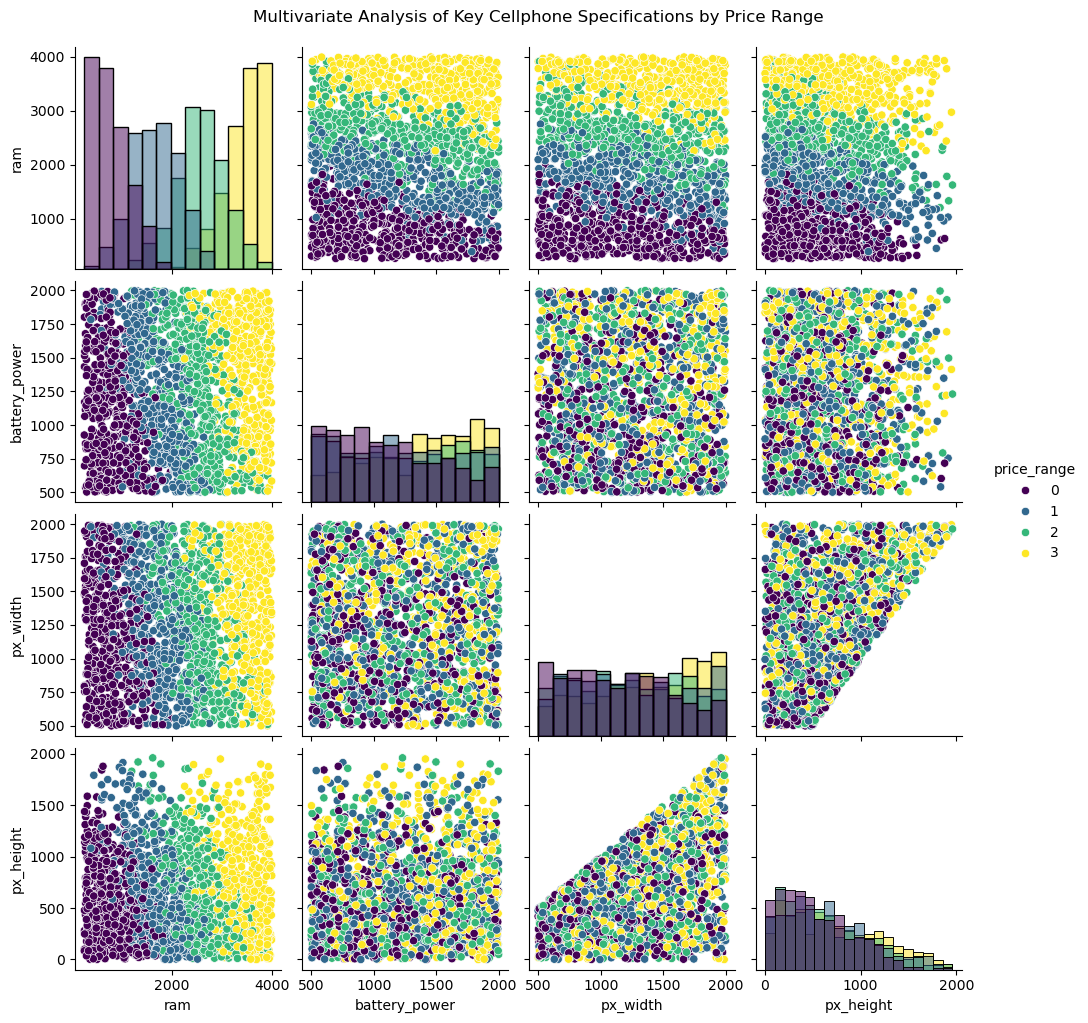

In [27]:
# Select key features for multivariate analysis
selected_features = [
    'ram',
    'battery_power',
    'px_width',
    'px_height',
    'price_range'
]

# Create pairplot
sns.pairplot(
    df[selected_features],
    hue='price_range',
    diag_kind='hist', palette='viridis'
)

plt.suptitle(
    'Multivariate Analysis of Key Cellphone Specifications by Price Range',
    y=1.02
)

plt.show()

#### **Insights:**

- The combination of **RAM and Battery Power** shows some variation across the four price ranges, with higher-priced cellphones tending to appear more frequently at higher RAM and battery capacity values. However, substantial overlap remains between the price categories.

- The combination of **RAM, Pixel Width, and Pixel Height** does not completely separate the four price ranges, as considerable overlap is observed. This indicates that **display resolution provides limited additional differentiation when considered alongside RAM**.

- The pairwise relationships among **RAM, Battery Power, Pixel Width, and Pixel Height** indicate that the selected hardware specifications, when considered together, show some variation across price ranges but do not completely distinguish all four categories.

- Overall, the multivariate analysis suggests that **RAM contributes the most to price-range separation**, while Battery Power and display specifications may provide additional information when considered together with other cellphone features.

## Outlier Analysis

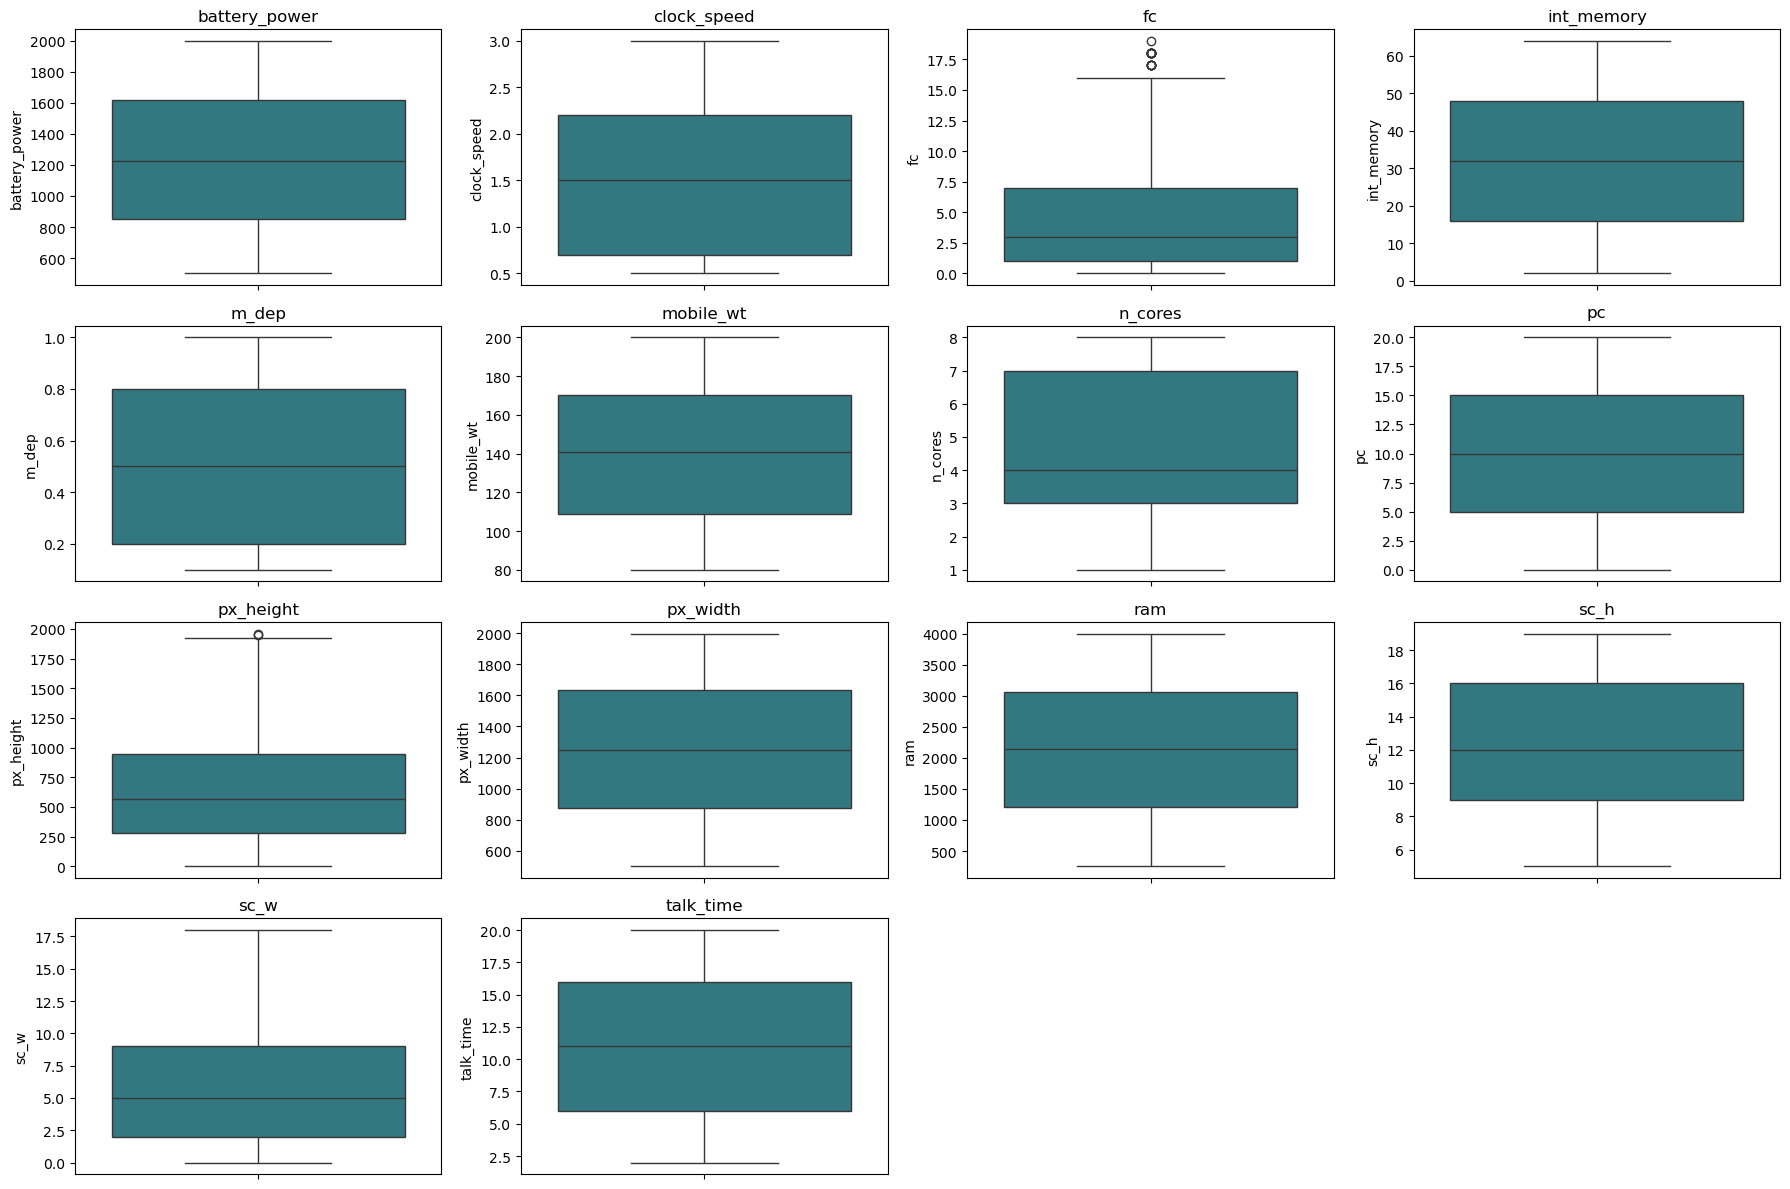

In [28]:
# Select numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude the target variable
numerical_features = numerical_features.drop('price_range')

# Select continuous numerical features only
continuous_features = [
    feature for feature in numerical_features
    if df[feature].nunique() > 2
]

# Plot boxplots for outlier analysis
plt.figure(figsize=(18, 12))

for i, feature in enumerate(continuous_features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[feature], color = '#26828E')
    plt.title(feature)

plt.tight_layout()
plt.show()

In [29]:
# Check the highest values
print("Top values of fc:")
print(df['fc'].sort_values(ascending=False).head(10))

print("\nTop values of px_height:")
print(df['px_height'].sort_values(ascending=False).head(10))

Top values of fc:
1705    19
1554    18
95      18
1406    18
1416    18
1882    18
1888    18
1387    18
305     18
1880    18
Name: fc, dtype: int64

Top values of px_height:
1771    1960
988     1949
894     1920
260     1914
1163    1901
1827    1899
1017    1895
1397    1878
1615    1874
305     1869
Name: px_height, dtype: int64


In [30]:
for feature in ['fc', 'px_height']:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    print(f"\nFeature: {feature}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of potential outliers: {len(outliers)}")
    print(f"Percentage: {len(outliers) / len(df) * 100:.2f}%")


Feature: fc
Q1: 1.0
Q3: 7.0
IQR: 6.0
Lower Bound: -8.0
Upper Bound: 16.0
Number of potential outliers: 18
Percentage: 0.90%

Feature: px_height
Q1: 282.75
Q3: 947.25
IQR: 664.5
Lower Bound: -714.0
Upper Bound: 1944.0
Number of potential outliers: 2
Percentage: 0.10%


#### **Insights:**
- The boxplot analysis shows **no major outlier concerns** across the continuous features. The IQR method was additionally applied to **`fc`** and **`px_height`** to quantify the potential outliers identified through the visual analysis.
- The IQR method identified a small number of potential upper-end outliers in **`fc`** (18 observations, 0.90%) and **`px_height`** (2 observations, 0.10%).
- The identified values represent **plausible cellphone specifications** and do not show evidence of obvious data-entry errors.

> Based on the boxplot and IQR analysis, **no outlier treatment was applied**. The identified observations were retained as they represent plausible variations in cellphone specifications, and removing or capping them could result in the **loss or alteration of potentially useful information** for predicting `price_range`.

## Data Preprocessing

### Feature Encoding

The dataset does **not contain any categorical features in text format**. Binary features such as **`blue`**, **`dual_sim`**, **`three_g`**, **`four_g`**, **`touch_screen`**, and **`wifi`** are already encoded as **0 (No)** and **1 (Yes)**. Therefore, **no additional feature encoding is required**.

### Separate Features (X) and Target (y)

In [31]:
# Separate features and target variable
X = df.drop('price_range', axis=1)
y = df['price_range']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 20)
Target shape: (2000,)


### Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [33]:
# Display the shape of the training and testing datasets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 20)
X_test shape: (400, 20)
y_train shape: (1600,)
y_test shape: (400,)


We use an **80/20 train-test split** with **stratification**, ensuring that both the training and testing sets maintain approximately the same proportion of all four **price range classes**. This helps create a fair and representative split, leading to a more reliable evaluation of the machine learning models.

With a dataset of **2,000 mobile phones**:
- **Training set (80%)**: **1,600 mobile phones** *(2,000 × 0.80 = 1,600)*
- **Testing set (20%)**: **400 mobile phones** *(2,000 × 0.20 = 400)*

# Feature Scaling

- Feature scaling is the process of bringing numerical features to a similar scale so that no feature dominates another due to its larger numerical values.

In [34]:
# Identify the Continuous Numerical Features
# Only continuous numerical features are scaled because they have varying numerical ranges.
# Binary features with values 0 and 1 are already on a consistent scale and are kept unchanged.

continuous_features = [
    feature for feature in X_train.columns
    if X_train[feature].nunique() > 2
]

print("Continuous Features:", continuous_features)

Continuous Features: ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']


## Initialize the StandardScaler

- `StandardScaler` is used to standardize the continuous numerical features to have a mean of **0** and a standard deviation of **1**.

- **Scaled Value = (Value − Mean) / Standard Deviation**

- After scaling, each continuous numerical feature will have approximately:
  - **Mean ≈ 0**
  - **Standard Deviation ≈ 1**

#### To avoid data leakage, the scaler is fitted only on the continuous features of the training dataset and then used to transform the corresponding continuous features in both the training and testing datasets.

In [35]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

In [36]:
# Create copies of train and test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform continuous features in training data
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Transform continuous features in test data using the same fitted scaler
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

## Scaling Continuous Numerical Features

Copies of the training and testing datasets are created to preserve the original data. `StandardScaler` is then applied only to the **continuous numerical features**.

The scaler is fitted on the training data to learn the mean and standard deviation of each continuous feature. The same fitted scaler is then used to transform the corresponding features in the testing data, ensuring consistent scaling while preventing **data leakage**.

In [37]:
### Verify Scaled Data
X_train_scaled.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
469,1.389193,1,-1.259189,1,1.309253,0,1.584829,-0.704590,-1.250335,-1.551637,0.350239,-0.798849,-1.285642,-0.363024,-0.781290,-0.177627,-0.896645,0,0,0
565,0.078406,1,-1.259189,0,1.770460,0,-0.003457,-1.396849,-0.768374,1.073159,0.844549,1.582302,1.637675,-1.547896,0.647082,1.875207,0.560944,0,0,1
396,-1.024573,0,1.187471,1,-0.074370,1,1.365755,1.372187,-1.392089,1.510625,0.350239,-1.361502,-0.199305,1.698985,-0.067104,0.506651,-0.896645,1,1,1
452,0.386692,0,-1.259189,1,-0.535577,1,0.106080,1.026057,-1.193634,-0.676705,-0.803150,0.832847,0.278589,1.649232,-0.781290,0.506651,-1.625440,1,0,1
325,-0.723138,0,0.698139,1,0.156234,0,-0.386837,-0.358460,-0.711673,1.073159,0.679779,-0.985650,-0.392794,-1.234632,-0.543228,0.278558,-1.078844,0,1,1


In [38]:
# Check the statistical summary of scaled continuous features
X_train_scaled[continuous_features].describe().round(2)

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
count,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.68,-1.26,-1.00,-1.65,-1.40,-1.70,-1.55,-1.63,-1.46,-1.74,-1.72,-1.73,-1.32,-1.63
25%,-0.88,-1.01,-0.77,-0.88,-1.05,-0.88,-0.68,-0.80,-0.82,-0.87,-0.84,-0.78,-0.86,-0.90
50%,-0.03,-0.04,-0.30,-0.03,-0.01,0.03,0.20,0.02,-0.18,0.00,0.01,-0.07,-0.18,0.01
75%,0.86,0.85,0.62,0.87,1.03,0.85,1.07,0.84,0.69,0.86,0.86,0.89,0.73,0.93
max,1.74,1.80,3.38,1.75,1.72,1.70,1.51,1.67,2.96,1.75,1.73,1.60,2.79,1.65


In [39]:
# Check the data types of all features after scaling
print(X_train_scaled.dtypes)

battery_power    float64
blue               int64
clock_speed      float64
dual_sim           int64
fc               float64
four_g             int64
int_memory       float64
m_dep            float64
mobile_wt        float64
n_cores          float64
pc               float64
px_height        float64
px_width         float64
ram              float64
sc_h             float64
sc_w             float64
talk_time        float64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object


- **`float64`** → Continuous numerical features that were standardized using `StandardScaler`.
- **`int64`** → Binary features with values **0 and 1**, which were retained in their original form and not scaled.

### Feature Engineering Note

The dataset already contains detailed features covering key aspects of mobile phones, such as **RAM, battery power, internal memory, screen resolution, camera specifications, and connectivity attributes**. These features provide sufficient information to distinguish between different **`price_range`** categories. Therefore, no additional derived or transformed features were created, and the original features were retained for model development.

### Scaling Decision for Model Training

Feature scaling was applied to the continuous numerical features for **Logistic Regression, KNN, SVM and Naive Bayes**, as these models are sensitive to feature scale. Tree-based models such as **Decision Tree, Random Forest, and XGBoost** do not require feature scaling because their splitting decisions are based on feature thresholds rather than distances or coefficient magnitudes. Therefore, the original unscaled features were used for these models.

# Model Building

The dataset has been effectively prepared through data cleaning, exploratory data analysis, train-test splitting, and feature scaling. The preprocessed data is now ready for building, training, and evaluating machine learning models to predict cellphone price ranges.


# LOGISTIC REGRESSION

In [40]:
# Train the Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
# Predict the price range for the test data
y_pred_lr = lr.predict(X_test_scaled)

## Evaluation Metrics

In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
ConfusionMatrixDisplay, classification_report)

In [43]:
# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

**Note:** Since the target variable **`price_range`** contains four classes, **Precision, Recall, and F1-score** are calculated using the **weighted average**, which accounts for the number of samples in each class and provides an overall performance measure.

In [44]:
# Display the evaluation metrics
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Accuracy : 0.9650
Precision: 0.9650
Recall   : 0.9650
F1-Score : 0.9650


### Classification Report

In [45]:
# Generate classification report
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



## Confusion Matrix

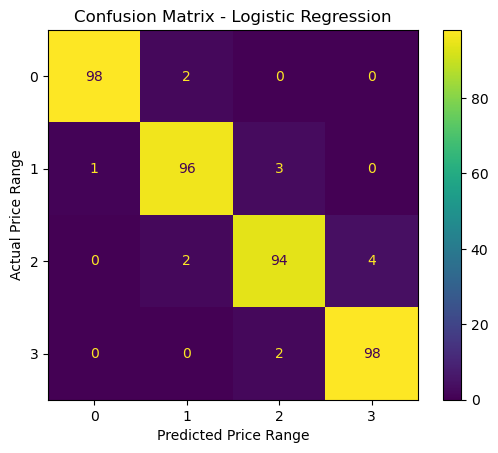

In [46]:
# Calculate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **98 were correctly classified** as Price Range 0. **2 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **96 were correctly classified** as Price Range 1. **1 cellphone was incorrectly predicted as Price Range 0**, and **3 cellphones were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **94 were correctly classified** as Price Range 2. **2 cellphones were incorrectly predicted as Price Range 1**, and **4 cellphones were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **98 were correctly classified** as Price Range 3. **2 cellphones were incorrectly predicted as Price Range 2**.

Overall, the Logistic Regression model correctly classified the majority of cellphones across all four **`price_range`** categories. The misclassifications mainly occurred between **adjacent price ranges**, particularly between **Price Ranges 1 and 2** and **2 and 3**, suggesting that cellphones in neighboring price categories may have similar specification patterns, making them relatively more difficult for the model to distinguish.

### Logistic Regression Model Conclusion

- The Logistic Regression model achieved **96% accuracy** with strong **Precision, Recall, and F1-score** across all four `price_range` categories.
- The model demonstrates that the available cellphone specifications provide sufficient information to effectively predict the **price category** of a cellphone.
- Overall, Logistic Regression serves as a **strong baseline model** for the Cellphone Price Range Prediction problem and provides a benchmark for evaluating the performance of other classification models.

# Decision Tree

In [47]:
# Import and Train the Model
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
# Make predictions on the test data
y_pred_dt = dt.predict(X_test)

## Calculate Evaluation Metrics

In [49]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

In [50]:
print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree Precision:", precision_dt)
print("Decision Tree Recall:", recall_dt)
print("Decision Tree F1-score:", f1_dt)

Decision Tree Accuracy: 0.83
Decision Tree Precision: 0.8318831447022742
Decision Tree Recall: 0.83
Decision Tree F1-score: 0.830168476083014


## Classification Report

In [51]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



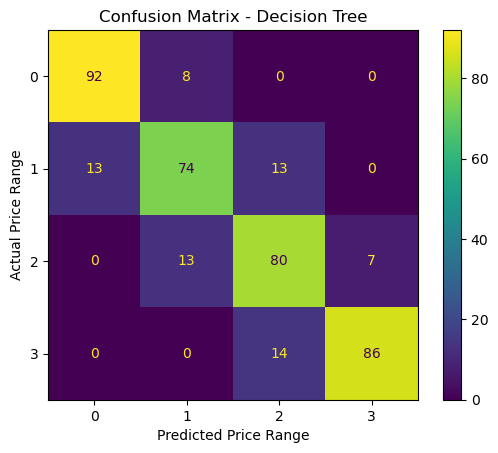

In [52]:
# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **92 were correctly classified** as Price Range 0. **8 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **74 were correctly classified** as Price Range 1. **13 cellphones were incorrectly predicted as Price Range 0**, and **13 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **80 were correctly classified** as Price Range 2. **13 cellphones were incorrectly predicted as Price Range 1**, and **7 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **86 were correctly classified** as Price Range 3. **14 cellphones were incorrectly predicted as Price Range 2**.

Overall, the Decision Tree model shows comparatively lower classification performance for the middle **Price Range 1 and Price Range 2** categories, with more confusion between these classes. In comparison, **Price Ranges 0 and 3** achieve higher correct classification rates, indicating that the model distinguishes these price segments more effectively than the intermediate categories.

## Hyperparameter Tuning for Decision Tree

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the hyperparameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20],
    'min_samples_split': [2, 3, 5, 10, 20],
    'min_samples_leaf': [1, 2, 3, 4, 5, 8],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Perform Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
grid_search_dt.fit(X_train, y_train)

# Display best parameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

# Display best cross-validation accuracy
print("\nBest Cross Validation Accuracy:")
print(grid_search_dt.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.8481249999999999


In [54]:
# Train the Decision Tree using the best parameters
best_dt = grid_search_dt.best_estimator_

best_dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
# Predict using the tuned model
y_pred_dt_tuned = best_dt.predict(X_test)

## Evaluation Metrics after Tuning

In [56]:
# Calculate evaluation metrics
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
precision_dt_tuned = precision_score(y_test, y_pred_dt_tuned, average='weighted')
recall_dt_tuned = recall_score(y_test, y_pred_dt_tuned, average='weighted')
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average='weighted')

In [57]:
# Display the results
print(f"Accuracy : {accuracy_dt_tuned:.3f}")
print(f"Precision: {precision_dt_tuned:.3f}")
print(f"Recall   : {recall_dt_tuned:.3f}")
print(f"F1 Score : {f1_dt_tuned:.3f}")

Accuracy : 0.868
Precision: 0.867
Recall   : 0.868
F1 Score : 0.867


## Classification Report After Tuning

In [58]:
print(classification_report(y_test, y_pred_dt_tuned))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.85      0.80      0.82       100
           2       0.78      0.80      0.79       100
           3       0.89      0.92      0.91       100

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



## Confusion Matrix

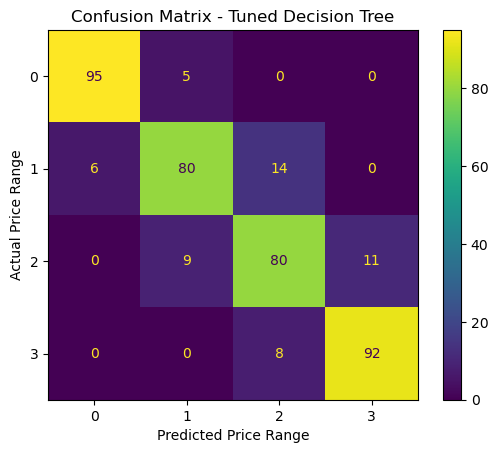

In [59]:
# Calculate confusion matrix
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_tuned,
    display_labels=best_dt.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **95 were correctly classified** as Price Range 0. **5 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **80 were correctly classified** as Price Range 1. **6 cellphones were incorrectly predicted as Price Range 0**, and **14 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **80 were correctly classified** as Price Range 2. **9 cellphones were incorrectly predicted as Price Range 1**, and **11 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **92 were correctly classified** as Price Range 3. **8 cellphones were incorrectly predicted as Price Range 2**.

Overall, hyperparameter tuning improved the Decision Tree's classification of **Price Ranges 0, 1, and 3**, while the performance for **Price Range 2 remained unchanged**. The tuned model continues to classify the lower and higher price segments more effectively, whereas **Price Ranges 1 and 2** remain comparatively more challenging to distinguish.

## Model Selection

**Hyperparameter tuning improved the Decision Tree** model's overall performance, particularly its ability to classify cellphones across the four `price_range` categories. The **tuned model achieved better classification performance** than the baseline model and was **therefore selected as the final Decision Tree model** for comparison with the other machine learning algorithms.

## Decision Tree Model Conclusion

- The tuned Decision Tree demonstrated **good overall predictive performance** in classifying cellphones into the four `price_range` categories based on their specifications.
- Its **tree-based structure provides an interpretable way to understand how cellphone specifications contribute to price category predictions**, making the model relatively easy to explain.
- Although other machine learning models may achieve higher predictive performance, the Decision Tree remains a **valuable and interpretable model** for cellphone price range prediction and provides a useful benchmark for comparison with other classification algorithms.

# Random Forest

In [60]:
# Import and Train the Model
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
# Make predictions using the Random Forest model
y_pred_rf = rf.predict(X_test)

## Calculate Evaluation Metrics

In [62]:
# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

In [63]:
# Display the results
print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall   : {recall_rf:.3f}")
print(f"F1 Score : {f1_rf:.3f}")

Accuracy : 0.880
Precision: 0.880
Recall   : 0.880
F1 Score : 0.880


## Classification Report

In [64]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



## Confusion Matrix

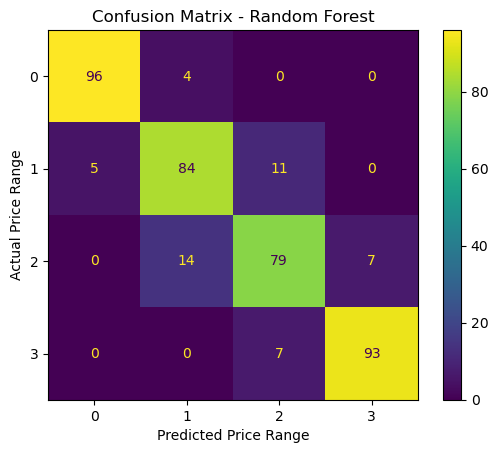

In [65]:
# Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **96 were correctly classified** as Price Range 0. **4 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **84 were correctly classified** as Price Range 1. **5 cellphones were incorrectly predicted as Price Range 0**, and **11 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **79 were correctly classified** as Price Range 2. **14 cellphones were incorrectly predicted as Price Range 1**, and **7 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **93 were correctly classified** as Price Range 3. **7 cellphones were incorrectly predicted as Price Range 2**.

Overall, the Random Forest model performs better in distinguishing the lower and higher cellphone price segments (**Price Ranges 0 and 3**), while **Price Ranges 1 and 2** show comparatively more misclassification. The higher confusion between neighboring price categories suggests that cellphones in these segments may have **overlapping specification patterns**, making their price ranges relatively more difficult for the model to distinguish.

## Hyperparameter Tuning for Random Forest

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_clf1 = RandomForestClassifier(random_state=42)

# Define the hyperparameter search space
random_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Perform Randomized Search
rf_cv = RandomizedSearchCV(
    estimator=rf_clf1,
    param_distributions=random_grid,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit Randomized Search
rf_cv.fit(X_train, y_train)

print("Best Parameters:")
print(rf_cv.best_params_)

print("\nBest Cross Validation Accuracy:")
print(rf_cv.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': True}

Best Cross Validation Accuracy:
0.87375


In [67]:
# Build the tuned Random Forest model using the best parameters
rf_tuned = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=30,
    bootstrap=True,
    random_state=42
)

# Train the tuned model
rf_tuned.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# Make predictions using the tuned Random Forest
y_pred_rf_tuned = rf_tuned.predict(X_test)

## Evaluation Metrics after tuning

In [69]:
# Calculate evaluation metrics
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned, average='weighted')
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned, average='weighted')
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted')

In [70]:
# Display the results
print(f"Accuracy : {accuracy_rf_tuned:.3f}")
print(f"Precision: {precision_rf_tuned:.3f}")
print(f"Recall   : {recall_rf_tuned:.3f}")
print(f"F1 Score : {f1_rf_tuned:.3f}")

Accuracy : 0.895
Precision: 0.895
Recall   : 0.895
F1 Score : 0.895


## Classification Report

In [71]:
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.83      0.83      0.83       100
           2       0.84      0.84      0.84       100
           3       0.97      0.95      0.96       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## Confusion Matrix After Tuning

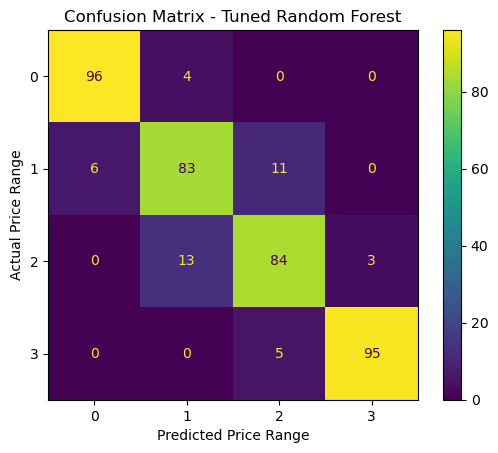

In [72]:
# Calculate confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_tuned,
    display_labels=rf_tuned.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **96 were correctly classified** as Price Range 0. **4 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **83 were correctly classified** as Price Range 1. **6 cellphones were incorrectly predicted as Price Range 0**, and **11 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **84 were correctly classified** as Price Range 2. **13 cellphones were incorrectly predicted as Price Range 1**, and **3 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **95 were correctly classified** as Price Range 3. **5 cellphones were incorrectly predicted as Price Range 2**.

Overall, the **Tuned Random Forest effectively distinguishes the lower and higher cellphone price segments (Price Ranges 0 and 3)**, while **Price Ranges 1 and 2** show comparatively more misclassification. The confusion between these neighboring categories suggests **overlapping cellphone specifications**, making them more difficult to distinguish. **Compared with the baseline Random Forest, the tuned model shows improved classification performance with fewer misclassifications.**

## Model Selection

The **tuned Random Forest** provided a more effective configuration for the cellphone price range classification task compared with the baseline Random Forest. The tuning process helped optimize the model's performance across the four `price_range` categories. Therefore, the **tuned Random Forest was retained as the final Random Forest model** for comparison with the other machine learning algorithms.

## Random Forest Model Conclusion

- The tuned Random Forest demonstrated **strong overall predictive performance** in classifying cellphones into the four `price_range` categories based on their specifications.
- Its **ensemble-based structure combines the predictions of multiple decision trees**, allowing the model to capture complex relationships among cellphone specifications and provide more robust predictions.
- Its ability to handle multiple features and identify non-linear patterns makes Random Forest a **suitable machine learning approach for cellphone price range prediction**.

# K-Nearest Neighbors (KNN)

In [73]:
# Import and train the KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
# Generate predictions using KNN model
y_pred_knn = knn.predict(X_test_scaled)

## Calculate Evaluation Metrics

In [75]:
# Calculate evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

In [76]:
# Display the results
print(f"Accuracy : {accuracy_knn:.3f}")
print(f"Precision: {precision_knn:.3f}")
print(f"Recall   : {recall_knn:.3f}")
print(f"F1 Score : {f1_knn:.3f}")

Accuracy : 0.600
Precision: 0.601
Recall   : 0.600
F1 Score : 0.599


## Classification Report

In [77]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))


Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.77      0.71       100
           1       0.43      0.44      0.44       100
           2       0.52      0.47      0.49       100
           3       0.80      0.72      0.76       100

    accuracy                           0.60       400
   macro avg       0.60      0.60      0.60       400
weighted avg       0.60      0.60      0.60       400



## Confusion Matrix

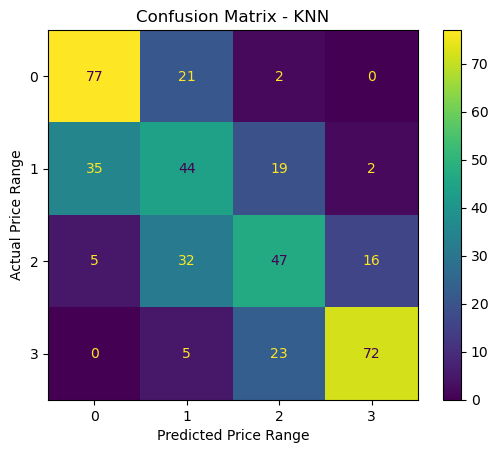

In [78]:
# Calculate confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **77 were correctly classified** as Price Range 0. **21 cellphones were incorrectly predicted as Price Range 1**, and **2 were incorrectly predicted as Price Range 2**.
- **Price Range 1:** Out of 100 cellphones, **44 were correctly classified** as Price Range 1. **35 cellphones were incorrectly predicted as Price Range 0**, and **19 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **47 were correctly classified** as Price Range 2. **5 cellphones were incorrectly predicted as Price Range 0**, **32 were incorrectly predicted as Price Range 1**, and **16 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **72 were correctly classified** as Price Range 3. **5 cellphones were incorrectly predicted as Price Range 1**, and **23 were incorrectly predicted as Price Range 2**.

Overall, the **KNN model performs relatively better in distinguishing Price Ranges 0 and 3**, while **Price Ranges 1 and 2 show substantial misclassification**. The higher confusion between neighboring price categories suggests that cellphones in these segments may have **similar or overlapping specifications**, making them more difficult for the KNN model to distinguish accurately.

## KNN Model Conclusion

- The KNN model demonstrated **moderate predictive performance** in classifying cellphones into the four `price_range` categories based on their specifications.
- Its **distance-based approach** allows it to classify a cellphone by considering the similarity of its specifications to those of nearby observations in the feature space.
- The model showed **higher confusion between the middle price ranges**, indicating that KNN may find it more challenging to distinguish cellphones with similar specifications across neighboring price segments.

# Support Vector Machine (SVM)

In [79]:
# Import and train the SVM model
from sklearn.svm import SVC

svm_clf = SVC(probability=True, random_state=42)

svm_clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [80]:
# Generate predictions using SVM model
y_pred_svm = svm_clf.predict(X_test_scaled)

## Calculate Evaluation Metrics

In [81]:
# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

In [82]:
# Display the results
print(f"Accuracy : {accuracy_svm:.3f}")
print(f"Precision: {precision_svm:.3f}")
print(f"Recall   : {recall_svm:.3f}")
print(f"F1 Score : {f1_svm:.3f}")

Accuracy : 0.902
Precision: 0.903
Recall   : 0.902
F1 Score : 0.903


## Classification Report

In [83]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))


Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.77      0.71       100
           1       0.43      0.44      0.44       100
           2       0.52      0.47      0.49       100
           3       0.80      0.72      0.76       100

    accuracy                           0.60       400
   macro avg       0.60      0.60      0.60       400
weighted avg       0.60      0.60      0.60       400



## Confusion Matrix

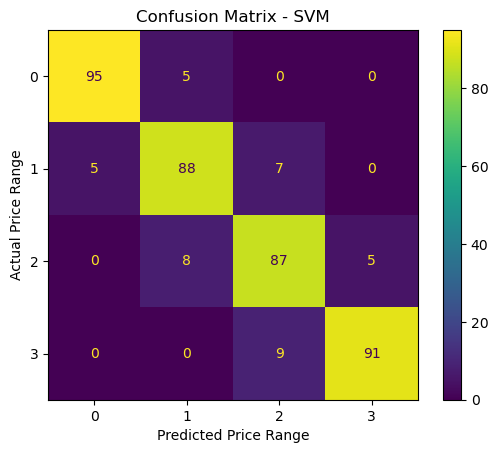

In [84]:
# Calculate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_clf.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **95 were correctly classified** as Price Range 0. **5 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **88 were correctly classified** as Price Range 1. **5 cellphones were incorrectly predicted as Price Range 0**, and **7 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **87 were correctly classified** as Price Range 2. **8 cellphones were incorrectly predicted as Price Range 1**, and **5 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **91 were correctly classified** as Price Range 3. **9 cellphones were incorrectly predicted as Price Range 2**.

Overall, the **SVM model performs well in distinguishing all four cellphone price segments**, with high correct classifications across each `price_range` category. Most misclassifications occur between **neighboring price ranges**, particularly between Price Ranges 1 and 2, suggesting that cellphones in these segments may have **similar specifications and overlapping feature patterns**. The relatively low misclassification across the four categories indicates that SVM can effectively identify **different cellphone price segments based on their specifications**.

## SVM Model Conclusion

- The SVM model demonstrated **strong predictive performance** in classifying cellphones across the four `price_range` categories based on their specifications.
- Its ability to identify **complex decision boundaries in the scaled feature space** enables it to effectively distinguish between different cellphone price segments.
- The model showed **good classification capability across all four price ranges**, making SVM a **suitable machine learning approach for cellphone price range prediction**.

# XGBoost (Extreme Gradient Boosting) Classifier

In [85]:
# Import the XGBoost model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

In [86]:
# XGBoost is tree-based, use the unscaled dataset
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [87]:
# Predict on the test data
y_pred_xgb = xgb_model.predict(X_test)

## Calculate Evaluation Metrics

In [88]:
# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

In [89]:
# Display the results
print(f"Accuracy : {accuracy_xgb:.3f}")
print(f"Precision: {precision_xgb:.3f}")
print(f"Recall   : {recall_xgb:.3f}")
print(f"F1 Score : {f1_xgb:.3f}")

Accuracy : 0.935
Precision: 0.935
Recall   : 0.935
F1 Score : 0.935


## Classification Report

In [90]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       0.94      0.93      0.93       100
           2       0.87      0.90      0.89       100
           3       0.96      0.91      0.93       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



## Confusion Matrix

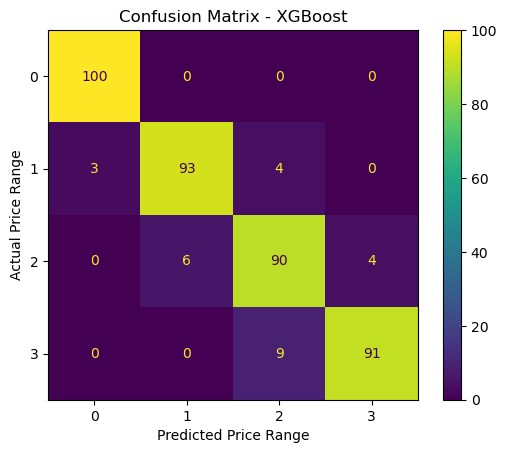

In [91]:
# Calculate confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=xgb_model.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **100 were correctly classified** as Price Range 0, showing that the model can accurately identify the lowest-priced cellphone segment based on its specifications.
- **Price Range 1:** Out of 100 cellphones, **93 were correctly classified** as Price Range 1. **3 cellphones were incorrectly predicted as Price Range 0**, and **4 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **90 were correctly classified** as Price Range 2. **6 cellphones were incorrectly predicted as Price Range 1**, and **4 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **91 were correctly classified** as Price Range 3. **9 cellphones were incorrectly predicted as Price Range 2**.

Overall, the **XGBoost model effectively distinguishes the four cellphone price segments**, with misclassifications mainly occurring between **adjacent price ranges**. The higher confusion between Price Ranges 2 and 3 suggests that cellphones in these segments may have **similar specifications**, making them more difficult to distinguish.

# Hyperparameter Tuning for XGBoost

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)

print("Best Parameters:")
print(random_xgb.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(random_xgb.best_score_, 4))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Best Cross-Validation Accuracy:
0.9013


In [93]:
tuned_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    subsample=0.8,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.2,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

tuned_xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [94]:
y_pred_tuned_xgb = tuned_xgb.predict(X_test)

## Evaluation Metrics for Tuned XGBoost

In [95]:
# Calculate evaluation metrics
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb, average='weighted')
recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb, average='weighted')
f1_tuned_xgb = f1_score(y_test, y_pred_tuned_xgb, average='weighted')

In [96]:
# Display the results
print(f"Accuracy : {accuracy_tuned_xgb:.3f}")
print(f"Precision: {precision_tuned_xgb:.3f}")
print(f"Recall   : {recall_tuned_xgb:.3f}")
print(f"F1 Score : {f1_tuned_xgb:.3f}")

Accuracy : 0.938
Precision: 0.937
Recall   : 0.938
F1 Score : 0.937


## Classification Report

In [97]:
print(classification_report(y_test, y_pred_tuned_xgb))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.92      0.93      0.93       100
           2       0.91      0.89      0.90       100
           3       0.95      0.95      0.95       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



## Confusion Matrix

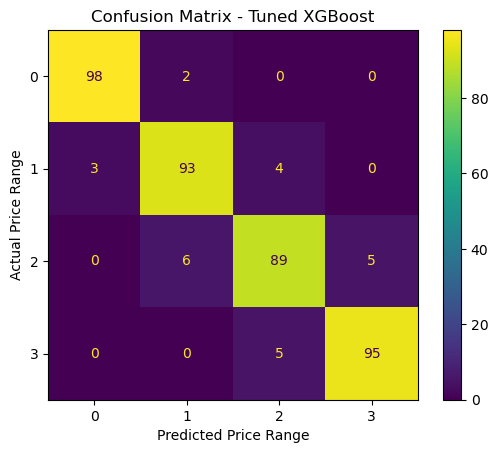

In [98]:
# Calculate confusion matrix
cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_xgb,
    display_labels=tuned_xgb.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **98 were correctly classified** as Price Range 0. **2 cellphones were incorrectly predicted as Price Range 1**.
- **Price Range 1:** Out of 100 cellphones, **93 were correctly classified** as Price Range 1. **3 cellphones were incorrectly predicted as Price Range 0**, and **4 were incorrectly predicted as Price Range 2**.
- **Price Range 2:** Out of 100 cellphones, **89 were correctly classified** as Price Range 2. **6 cellphones were incorrectly predicted as Price Range 1**, and **5 were incorrectly predicted as Price Range 3**.
- **Price Range 3:** Out of 100 cellphones, **95 were correctly classified** as Price Range 3. **5 cellphones were incorrectly predicted as Price Range 2**.

Overall, the **Tuned XGBoost model effectively distinguishes the four cellphone price segments**, with misclassifications mainly occurring between **adjacent price ranges**. The higher confusion between Price Ranges 1 and 2 suggests that cellphones in these segments may have **similar specifications**, making them more difficult to distinguish. **Compared with the baseline XGBoost, the tuned model shows improved classification performance, with fewer misclassifications and more correctly classified cellphones across the price ranges.**

## Model Selection

The **Tuned XGBoost model** was selected over the baseline XGBoost model based on its overall evaluation performance. The tuned model achieved a slight improvement across **Accuracy, Precision, Recall, and F1-score**, indicating better overall classification performance. Although the improvement was marginal, the **Tuned XGBoost** provided the best overall performance and was therefore selected as the final XGBoost model for the cellphone price range prediction task.

## XGBoost Model Conclusion

- The **tuned XGBoost model** demonstrated **excellent performance** in predicting cellphone price ranges, showing that cellphone specifications provide sufficient information to distinguish between different price segments.
- The model's ability to learn complex relationships among features makes it well suited for **multi-class cellphone price range prediction**.
- Overall, the **tuned XGBoost model** proved to be a **reliable and effective solution** for classifying cellphones into their respective price ranges based on their specifications.

# Guassian Naive Bayes

In [99]:
from sklearn.naive_bayes import GaussianNB

# Build the Gaussian Naive Bayes model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [100]:
# Make predictions on the test set
y_pred_gnb = gnb.predict(X_test_scaled)

## Calculate Evaluation Metrics

In [101]:
# Calculate evaluation metrics
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb, average='weighted')
recall_gnb = recall_score(y_test, y_pred_gnb, average='weighted')
f1_gnb = f1_score(y_test, y_pred_gnb, average='weighted')

In [102]:
print("Accuracy:", accuracy_gnb)
print("Precision:", precision_gnb)
print("Recall:", recall_gnb)
print("F1-Score:", f1_gnb)

Accuracy: 0.81
Precision: 0.8113261105197412
Recall: 0.81
F1-Score: 0.8104578013732255


## Classification Report

In [103]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_gnb))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       100
           1       0.71      0.69      0.70       100
           2       0.70      0.73      0.71       100
           3       0.91      0.92      0.92       100

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



## Confusion Matrix

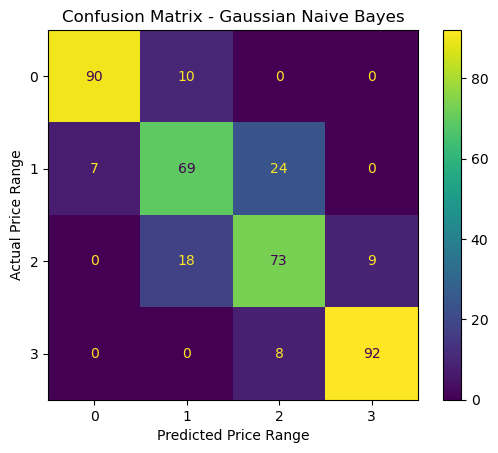

In [104]:
# Calculate confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=gnb.classes_
)

disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.show()

### **Insights:**

- **Price Range 0:** Out of 100 cellphones, **90 were correctly classified** as Price Range 0, while **10 were incorrectly predicted as Price Range 1**.

- **Price Range 1:** Out of 100 cellphones, **69 were correctly classified** as Price Range 1. **7 were incorrectly predicted as Price Range 0**, and **24 were incorrectly predicted as Price Range 2**.

- **Price Range 2:** Out of 100 cellphones, **73 were correctly classified** as Price Range 2. **18 were incorrectly predicted as Price Range 1**, and **9 were incorrectly predicted as Price Range 3**.

- **Price Range 3:** Out of 100 cellphones, **92 were correctly classified** as Price Range 3, while **8 were incorrectly predicted as Price Range 2**.

Overall, the **Gaussian Naive Bayes model showed relatively better classification for Price Ranges 0 and 3**, while it experienced more difficulty distinguishing between the intermediate **Price Ranges 1 and 2**. The misclassifications were primarily between **adjacent price ranges**, indicating that these segments may have overlapping cellphone specifications. 

## Gaussian Naive Bayes Model Conclusion

- The **Gaussian Naive Bayes model** demonstrated **reasonable classification performance** in predicting the four cellphone price ranges, with better performance for the lower and higher price segments.

- The model showed greater difficulty distinguishing between the **middle price ranges**, where cellphone specifications may overlap, resulting in more misclassifications between Price Ranges 1 and 2.

- Overall, Gaussian Naive Bayes provided a useful baseline for comparison but **did not achieve performance comparable to the higher-performing models** evaluated in this project.

### Hyperparameter Tuning Strategy

Hyperparameter tuning was performed for **Decision Tree, Random Forest, and XGBoost**, as these tree-based models contain several important parameters that control model complexity and predictive performance. **GridSearchCV** was used to systematically evaluate predefined parameter combinations using **Accuracy as the scoring metric**, which is appropriate because the four price-range classes are perfectly balanced.

### Impact of Hyperparameter Tuning

Hyperparameter tuning improved the performance of all three selected tree-based models, with the **most noticeable improvement observed in Decision Tree**, while Random Forest and XGBoost showed **smaller gains**. The tuned versions were therefore carried forward for the final model comparison.

# Model Comparison Report

This section compares the performance of all the machine learning models using multiple evaluation metrics, including **Accuracy, Precision, Recall,** and **F1-Score**. The comparison helps identify the most suitable model for **cellphone price range classification**.

In [105]:
# Model Comparison

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'KNN', 'SVM', 'XGBoost (Tuned)', 'Gaussian Naive Bayes'],
    'Accuracy': [accuracy_lr, accuracy_dt_tuned, accuracy_rf_tuned, accuracy_knn, accuracy_svm, accuracy_tuned_xgb, accuracy_gnb],
    'Precision': [precision_lr, precision_dt_tuned, precision_rf_tuned, precision_knn, precision_svm, precision_tuned_xgb, precision_gnb],
    'Recall': [recall_lr, recall_dt_tuned, recall_rf_tuned, recall_knn, recall_svm, recall_tuned_xgb, recall_gnb],
    'F1-Score': [f1_lr, f1_dt_tuned, f1_rf_tuned, f1_knn, f1_svm, f1_tuned_xgb, f1_gnb]
})

# Round values to 3 decimal places
model_comparison = model_comparison.round(3)

# Sort models based on Accuracy
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

# Reset index
model_comparison.reset_index(drop=True, inplace=True)

# Display comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.965,0.965,0.965,0.965
1,XGBoost (Tuned),0.938,0.937,0.938,0.937
2,SVM,0.902,0.903,0.902,0.903
3,Random Forest (Tuned),0.895,0.895,0.895,0.895
4,Decision Tree (Tuned),0.868,0.867,0.868,0.867
5,Gaussian Naive Bayes,0.810,0.811,0.810,0.810
6,KNN,0.600,0.601,0.600,0.599


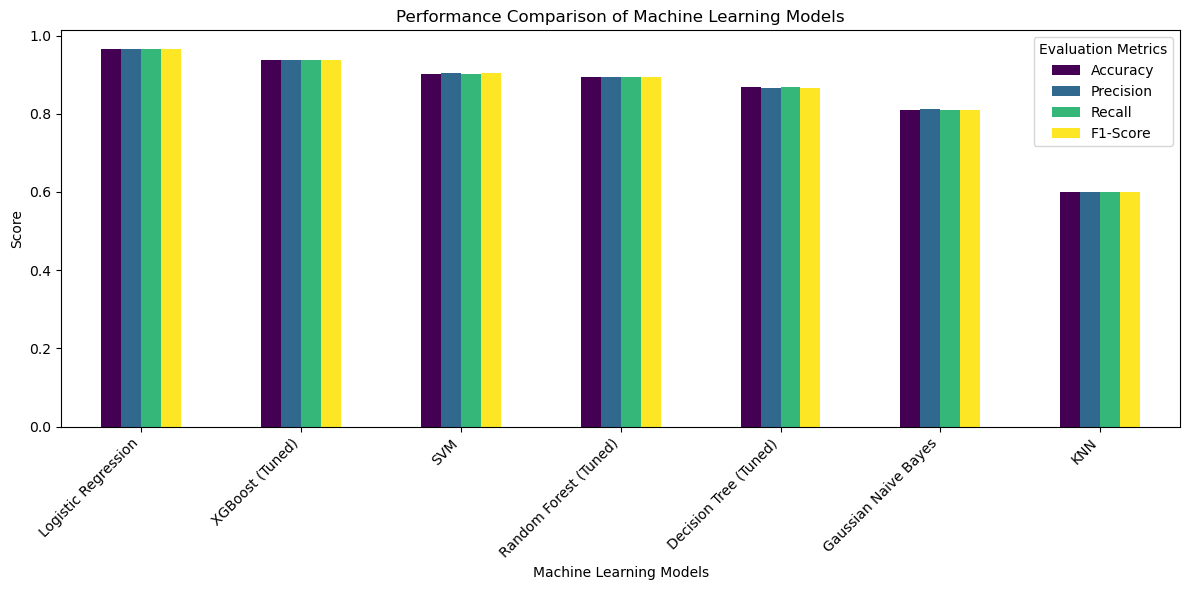

In [106]:
# Plot model performance comparison

model_comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(12, 6),
    colormap='viridis'
)

plt.title('Performance Comparison of Machine Learning Models')
plt.xlabel('Machine Learning Models')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Evaluation Metrics')
plt.tight_layout()
plt.show()

## **Model Comparison Summary**

The performance of seven machine learning models—**Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), XGBoost,** and **Gaussian Naive Bayes**—was evaluated using **Accuracy, Precision, Recall, and F1-Score**.

### **Performance Analysis**

- **Logistic Regression** achieved the **highest overall performance**, with:
  - **Accuracy:** **96.5%**
  - **Precision:** **96.5%**
  - **Recall:** **96.5%**
  - **F1-Score:** **96.5%**

  These results indicate that Logistic Regression provides the most balanced and reliable classification performance among all the evaluated models for predicting the four cellphone price ranges.

- **Tuned XGBoost** achieved the **second-highest overall performance**, with an Accuracy of **93.8%**, demonstrating strong capability in capturing complex relationships among cellphone specifications.

- **SVM** and **Tuned Random Forest** also demonstrated good classification performance, achieving Accuracy scores of **90.2%** and **89.5%**, respectively.

- **Tuned Decision Tree** achieved an Accuracy of **86.8%**, while **Gaussian Naive Bayes** achieved **81.0%**. **KNN** showed the lowest overall performance with an Accuracy of **60.0%**.

---

## **Final Model Selection**

After evaluating all models using multiple performance metrics, **Logistic Regression** was selected as the **best-performing model** for cellphone price range prediction.

### **Model Selection Justification**

For a multiclass classification problem, the model should perform consistently across the different price-range classes while maintaining a strong balance between correct and incorrect predictions.

- **High Accuracy** indicates that the model correctly classifies a large proportion of cellphones into their respective price ranges.
- **High Precision** indicates that the model makes reliable predictions for the assigned price ranges.
- **High Recall** indicates that the model effectively identifies cellphones belonging to their actual price ranges.
- **High F1-Score** demonstrates a strong balance between Precision and Recall.

Among all evaluated models, **Logistic Regression achieved the highest Accuracy, Precision, Recall, and F1-Score, with each metric reaching 96.5%**. This consistent performance demonstrates its ability to reliably classify cellphones across the four price ranges.

## Feature Importance Analysis

To understand which cellphone specifications contribute most to predicting the four price ranges, feature importance was analyzed using the coefficients of the final **Logistic Regression** model. Since Logistic Regression does not provide a direct `feature_importances_` attribute, the **absolute values of the model coefficients** were used as an indicator of feature influence. As this is a multiclass classification problem, the **mean absolute coefficient across all four price-range classes** was calculated to obtain an overall feature-importance score for each feature.

In [107]:
# Calculate feature importance from Logistic Regression coefficients
feature_importance_lr = np.mean(np.abs(lr.coef_), axis=0)

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance_lr
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
feature_importance_df

,Feature,Importance
13,ram,7.158968
0,battery_power,1.784646
12,px_width,1.053434
11,px_height,1.015789
8,mobile_wt,0.306580
19,wifi,0.228548
5,four_g,0.142549
3,dual_sim,0.139282
6,int_memory,0.126137
1,blue,0.103661


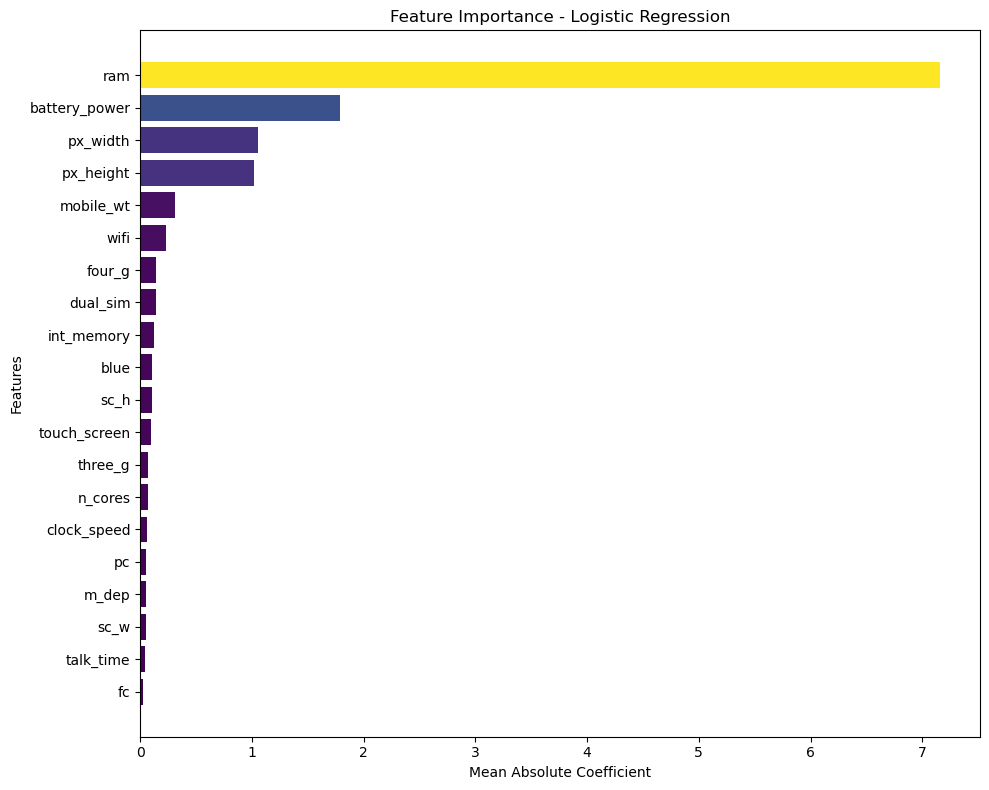

In [108]:
# Plot feature importance
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color=plt.cm.viridis(
        feature_importance_df['Importance'] / feature_importance_df['Importance'].max()
    )
)

plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Mean Absolute Coefficient')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

- **RAM** is the most influential feature in predicting cellphone price ranges, with a substantially higher importance score than the other features.
- **Battery Power**, **Pixel Width**, and **Pixel Height** are the next most influential features, indicating that battery capacity and display resolution also contribute to distinguishing between different price segments.
- Features such as **Mobile Weight, Wi-Fi, 4G, and Dual SIM** have comparatively lower importance, while several other features show relatively limited influence on the model's predictions.
- Overall, the analysis indicates that **RAM, battery capacity, and display resolution** are the most influential specifications for distinguishing cellphone price ranges in this dataset.

## Business Analysis and Business Impact

The developed machine learning model can help cellphone businesses make data-driven decisions by predicting the appropriate price range of a cellphone based on its specifications. This can support product planning, market segmentation, product positioning, and business expansion.

### How the Model Can Help Expand the Business

- **New Product Planning:** The model can help businesses evaluate proposed cellphone configurations and estimate their likely price segment before launching new products. This can support better product planning and reduce the risk of mispositioning a new product.

- **Market Segmentation:** The predicted price ranges can help businesses target different customer segments, including budget, mid-range, and premium markets. This enables businesses to develop products that address the needs of a broader customer base.

- **Pricing Strategy:** The model can support businesses in estimating the appropriate price segment for a new cellphone based on its specifications, helping them make more informed pricing and product positioning decisions.

- **Product Portfolio Expansion:** Businesses can use the model to identify opportunities for introducing new products across different price segments. Expanding the product portfolio can help the business reach new customer groups and increase its market coverage.

- **Product Positioning:** The model can support businesses in positioning products within appropriate price segments based on their specifications, helping maintain clear differentiation between budget, mid-range, and premium offerings.

- **Competitive Product Analysis:** The model can provide an additional data-driven perspective for evaluating cellphone specifications and understanding how products may fit within different price segments. This can support businesses in planning competitive product offerings.

- **Portfolio Optimization:** Businesses can use price-range predictions to maintain a balanced product portfolio across different market segments and identify potential gaps where new products could be introduced.

- **Inventory and Stock Planning:** Predicted price segments can support better inventory planning and allocation of products across different categories, helping businesses align stock levels with their target market strategy.

- **Data-Driven Decision-Making:** By combining model predictions with feature importance insights, businesses can make more informed decisions regarding product design, market targeting, and portfolio expansion.

### Business Recommendation


Based on the analysis, businesses should give particular attention to **RAM, Battery Power, Pixel Width, and Pixel Height** when developing and positioning cellphones for different price segments. The predictive model can be integrated into the product planning process to estimate the expected price range of new cellphone configurations and support data-driven decisions regarding product design, market segmentation, and portfolio expansion.

Overall, the model can help cellphone businesses better align **cellphone specifications with target price segments**, enabling them to identify market opportunities, develop products for different customer groups, and support sustainable business expansion.

# **Challenges Faced and Techniques Used**

| **Challenge** | **Technique Used** | **Reason** |
|---------------|--------------------|------------|
| Understanding individual feature distributions | Grouped features during **Univariate Analysis** and used appropriate visualizations | Helped identify distributions and patterns in cellphone specifications. |
| Understanding relationships between features and price range | Grouped relevant features during **Bivariate Analysis** and used appropriate visualizations | Helped identify relationships between cellphone specifications and price ranges. |
| Understanding relationships among multiple variables | Performed **Multivariate Analysis** | Helped examine combined relationships among important features and price range. |
| Identifying potential outliers | Applied the **IQR (Interquartile Range) method** and retained the identified outliers | Outliers were considered valid observations and were retained to preserve the information in the dataset. |
| Selecting suitable machine learning algorithms | Evaluated **Logistic Regression, Decision Tree, Random Forest, KNN, SVM, XGBoost,** and **Gaussian Naive Bayes** | Helped identify the best-performing model for the four price ranges. |
| Handling multi-class model evaluation | Used **weighted averaging** for evaluation metrics such as **Precision, Recall, and F1-score** | Provided an overall performance measure by considering the contribution of each class based on its number of samples. |
| Improving model performance | Applied hyperparameter tuning to **Decision Tree, Random Forest,** and **XGBoost** using **GridSearchCV with `scoring='accuracy'`** | Helped identify better parameter combinations and improve model performance. |
| Selecting the final prediction model | Compared the performance of all evaluated models | **Logistic Regression** achieved the highest overall performance with **96.5%** across all four metrics. |
| Identifying influential cellphone specifications | Performed **Feature Importance Analysis** using Logistic Regression coefficients | Identified features that most influenced price-range prediction. |
| Translating model insights into business value | Prepared a **Business Analysis and Business Impact** report | Connected model findings to product planning and business expansion. |

# **Conclusion**

This project successfully developed a **machine learning-based Cellphone Price Range Prediction model** to classify cellphones into four different price segments based on their specifications. Multiple classification algorithms were evaluated, and **Logistic Regression** achieved the **best overall performance**, making it the most suitable model for this dataset.

The analysis identified **RAM** as the feature with the **strongest relationship with cellphone price range**, while **Battery Power, Pixel Width, and Pixel Height** also showed positive relationships with the target variable. These insights can help businesses make data-driven decisions related to **new product planning, market segmentation, pricing strategy, product positioning, and product portfolio expansion**.

The developed model provides a reliable approach for classifying cellphone price segments and can serve as a **decision-support tool** for cellphone businesses to better align product specifications with target markets, identify new market opportunities, and support sustainable business growth.